# **Project: Predicting London House Prices**

## 1.1 Import Modules and data

In [38]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
import xgboost as xgb
import lightgbm as lgb
from sklearn.model_selection import cross_val_score

##### Load Data

In [39]:
df = pd.read_csv("Data/house_prices.csv")

## 1.2 Data Inspection

### Getting started with data analysis

In [40]:
df.head()

,fullAddress,postcode,country,outcode,latitude,longitude,bathrooms,bedrooms,floorAreaSqM,livingRooms,...,saleEstimate_upperPrice,saleEstimate_confidenceLevel,saleEstimate_ingestedAt,saleEstimate_valueChange.numericChange,saleEstimate_valueChange.percentageChange,saleEstimate_valueChange.saleDate,history_date,history_price,history_percentageChange,history_numericChange
0,"Flat 9, 35 Furnival Street, London, EC4A 1JQ",EC4A 1JQ,England,EC4A,51.517282,-0.110314,1.0,1.0,45.0,1.0,...,630000.0,HIGH,2024-10-07T13:26:59.894Z,244000.0,68.539326,2010-03-30,1995-01-02,830000,NaN,NaN
1,"Flat 6, 35 Furnival Street, London, EC4A 1JQ",EC4A 1JQ,England,EC4A,51.517282,-0.110314,NaN,NaN,NaN,NaN,...,660000.0,MEDIUM,2024-10-07T13:26:59.894Z,425000.0,242.857143,2000-05-26,1995-01-02,830000,NaN,NaN
2,"Flat 35, Octavia House, Medway Street, London,...",SW1P 2TA,England,SW1P,51.495505,-0.132379,2.0,2.0,71.0,1.0,...,834000.0,MEDIUM,2025-01-10T11:04:57.114Z,49000.0,6.901408,2019-09-04,1995-01-03,249950,NaN,NaN
3,"24 Chester Court, Lomond Grove, London, SE5 7HS",SE5 7HS,England,SE5,51.478185,-0.092201,1.0,1.0,64.0,1.0,...,407000.0,HIGH,2024-10-07T13:26:59.894Z,28000.0,7.777778,2024-01-25,1995-01-03,32000,NaN,NaN
4,"18 Alexandra Gardens, London, N10 3RL",N10 3RL,England,N10,51.588774,-0.139599,1.0,4.0,137.0,2.0,...,1324000.0,HIGH,2024-10-07T13:26:59.894Z,81000.0,6.864407,2022-12-14,1995-01-03,133000,NaN,NaN


In [41]:
from IPython.display import display, HTML

display(HTML("<style>.container { width:100% !important; }</style>"))

In [42]:
display(df.head())

,fullAddress,postcode,country,outcode,latitude,longitude,bathrooms,bedrooms,floorAreaSqM,livingRooms,...,saleEstimate_upperPrice,saleEstimate_confidenceLevel,saleEstimate_ingestedAt,saleEstimate_valueChange.numericChange,saleEstimate_valueChange.percentageChange,saleEstimate_valueChange.saleDate,history_date,history_price,history_percentageChange,history_numericChange
0,"Flat 9, 35 Furnival Street, London, EC4A 1JQ",EC4A 1JQ,England,EC4A,51.517282,-0.110314,1.0,1.0,45.0,1.0,...,630000.0,HIGH,2024-10-07T13:26:59.894Z,244000.0,68.539326,2010-03-30,1995-01-02,830000,NaN,NaN
1,"Flat 6, 35 Furnival Street, London, EC4A 1JQ",EC4A 1JQ,England,EC4A,51.517282,-0.110314,NaN,NaN,NaN,NaN,...,660000.0,MEDIUM,2024-10-07T13:26:59.894Z,425000.0,242.857143,2000-05-26,1995-01-02,830000,NaN,NaN
2,"Flat 35, Octavia House, Medway Street, London,...",SW1P 2TA,England,SW1P,51.495505,-0.132379,2.0,2.0,71.0,1.0,...,834000.0,MEDIUM,2025-01-10T11:04:57.114Z,49000.0,6.901408,2019-09-04,1995-01-03,249950,NaN,NaN
3,"24 Chester Court, Lomond Grove, London, SE5 7HS",SE5 7HS,England,SE5,51.478185,-0.092201,1.0,1.0,64.0,1.0,...,407000.0,HIGH,2024-10-07T13:26:59.894Z,28000.0,7.777778,2024-01-25,1995-01-03,32000,NaN,NaN
4,"18 Alexandra Gardens, London, N10 3RL",N10 3RL,England,N10,51.588774,-0.139599,1.0,4.0,137.0,2.0,...,1324000.0,HIGH,2024-10-07T13:26:59.894Z,81000.0,6.864407,2022-12-14,1995-01-03,133000,NaN,NaN


In [43]:
df.sample(5)

,fullAddress,postcode,country,outcode,latitude,longitude,bathrooms,bedrooms,floorAreaSqM,livingRooms,...,saleEstimate_upperPrice,saleEstimate_confidenceLevel,saleEstimate_ingestedAt,saleEstimate_valueChange.numericChange,saleEstimate_valueChange.percentageChange,saleEstimate_valueChange.saleDate,history_date,history_price,history_percentageChange,history_numericChange
196422,"8 Bourne House, St Vincent Street, London, W1U...",W1U 4DB,England,W1U,51.518885,-0.152207,1.0,NaN,28.0,1.0,...,368000.0,LOW,2025-01-10T11:04:57.114Z,66000.0,27.500000,2015-01-09,2015-01-09,240000,400.0,192000.0
277147,"31 Ashleigh Road, London, SE20 7YW",SE20 7YW,England,SE20,51.402695,-0.060191,1.0,3.0,100.0,1.0,...,638000.0,HIGH,2024-10-07T13:26:59.894Z,31000.0,5.281385,2021-11-15,2021-05-04,410000,NaN,NaN
227083,"Flat 12, Howick Mansions, 831 Woolwich Road, L...",SE7 8LL,England,SE7,51.492661,0.045028,2.0,NaN,70.0,1.0,...,328000.0,HIGH,2025-01-10T11:04:57.114Z,18000.0,6.101695,2024-07-29,2017-07-28,280000,124.0,155000.0
131587,"Flat 2, 245 Gray's Inn Road, London, WC1X 8QY",WC1X 8QY,England,WC1X,51.528493,-0.119639,1.0,1.0,42.0,1.0,...,488000.0,MEDIUM,2024-10-07T13:26:59.894Z,199000.0,80.855397,2007-06-21,2007-06-21,245500,NaN,NaN
334961,"Apartment 98, 60 St John's Wood Road, London, ...",NW8 7HN,England,NW8,51.529405,-0.169313,NaN,NaN,NaN,NaN,...,2252000.0,LOW,2025-02-06T14:05:28.374Z,-5399000.0,-74.213058,2022-12-16,2022-12-16,7275000,NaN,NaN


In [44]:
df.shape #418201 rows and 28 columns

(418201, 28)

In [45]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418201 entries, 0 to 418200
Data columns (total 28 columns):
 #   Column                                     Non-Null Count   Dtype  
---  ------                                     --------------   -----  
 0   fullAddress                                418201 non-null  object 
 1   postcode                                   418201 non-null  object 
 2   country                                    418201 non-null  object 
 3   outcode                                    418201 non-null  object 
 4   latitude                                   418201 non-null  float64
 5   longitude                                  418201 non-null  float64
 6   bathrooms                                  340270 non-null  float64
 7   bedrooms                                   377665 non-null  float64
 8   floorAreaSqM                               392991 non-null  float64
 9   livingRooms                                357701 non-null  float64
 10  tenure  

In [46]:
df.describe(include = 'all')

,fullAddress,postcode,country,outcode,latitude,longitude,bathrooms,bedrooms,floorAreaSqM,livingRooms,...,saleEstimate_upperPrice,saleEstimate_confidenceLevel,saleEstimate_ingestedAt,saleEstimate_valueChange.numericChange,saleEstimate_valueChange.percentageChange,saleEstimate_valueChange.saleDate,history_date,history_price,history_percentageChange,history_numericChange
count,418201,418201,418201,418201,418201.000000,418201.000000,340270.000000,377665.000000,392991.000000,357701.000000,...,4.175610e+05,417561,417561,4.175610e+05,417561.000000,417561,418201,4.182010e+05,237982.000000,2.379820e+05
unique,137760,48392,1,168,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,3,4,NaN,NaN,6241,8325,NaN,NaN,NaN
top,"74 Western Beach Apartments, 36 Hanover Avenue...",SW1P 3AN,England,SE18,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,HIGH,2024-10-07T13:26:59.894Z,NaN,NaN,2021-06-30,2021-06-30,NaN,NaN,NaN
freq,224,366,418201,8307,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,300772,282304,NaN,NaN,2170,1071,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,51.507522,-0.101426,1.444265,2.474884,98.926543,1.282275,...,9.777633e+05,NaN,NaN,2.886077e+04,29.278605,NaN,NaN,6.395840e+05,105.877778,2.528741e+05
std,NaN,NaN,NaN,NaN,0.056171,0.086930,0.724478,1.160506,55.938911,0.574412,...,1.037913e+06,NaN,NaN,1.080893e+06,362.350731,NaN,NaN,1.327933e+06,338.849944,8.024032e+05
min,NaN,NaN,NaN,NaN,51.385708,-0.347055,1.000000,1.000000,10.000000,1.000000,...,9.300000e+04,NaN,NaN,-1.053770e+08,-99.763196,NaN,NaN,1.000000e+04,-99.890110,-7.390000e+07
25%,NaN,NaN,NaN,NaN,51.464315,-0.155996,1.000000,2.000000,63.000000,1.000000,...,4.750000e+05,NaN,NaN,1.100000e+04,2.105263,NaN,NaN,2.280000e+05,17.833333,4.849500e+04
50%,NaN,NaN,NaN,NaN,51.501581,-0.108482,1.000000,2.000000,84.000000,1.000000,...,6.630000e+05,NaN,NaN,3.500000e+04,6.260870,NaN,NaN,4.000000e+05,52.857143,1.300000e+05
75%,NaN,NaN,NaN,NaN,51.548515,-0.043582,2.000000,3.000000,116.000000,1.000000,...,1.054000e+06,NaN,NaN,8.600000e+04,13.554987,NaN,NaN,6.650000e+05,114.285714,2.870000e+05


## 1.3 Data Quality Check
### Investigate the dataset for missing or problematic data

In [47]:
#show columns with missing data and counts

is_missing_cols = df.isna().sum().sort_values(ascending=False)
is_missing_cols[is_missing_cols >0]

history_numericChange                        180219
history_percentageChange                     180219
currentEnergyRating                           84526
bathrooms                                     77931
livingRooms                                   60500
bedrooms                                      40536
floorAreaSqM                                  25210
tenure                                        11512
rentEstimate_upperPrice                        1741
rentEstimate_lowerPrice                        1741
rentEstimate_currentPrice                      1741
propertyType                                   1136
saleEstimate_upperPrice                         640
saleEstimate_valueChange.saleDate               640
saleEstimate_valueChange.percentageChange       640
saleEstimate_valueChange.numericChange          640
saleEstimate_ingestedAt                         640
saleEstimate_confidenceLevel                    640
saleEstimate_currentPrice                       640
saleEstimate

In [48]:
columns_with_missing_data = is_missing_cols[is_missing_cols>0].index
len(columns_with_missing_data)

20

In [49]:
#show percentage of missing data within columns
df[columns_with_missing_data].isna().mean().round(3)*100

history_numericChange                        43.1
history_percentageChange                     43.1
currentEnergyRating                          20.2
bathrooms                                    18.6
livingRooms                                  14.5
bedrooms                                      9.7
floorAreaSqM                                  6.0
tenure                                        2.8
rentEstimate_upperPrice                       0.4
rentEstimate_lowerPrice                       0.4
rentEstimate_currentPrice                     0.4
propertyType                                  0.3
saleEstimate_upperPrice                       0.2
saleEstimate_valueChange.saleDate             0.2
saleEstimate_valueChange.percentageChange     0.2
saleEstimate_valueChange.numericChange        0.2
saleEstimate_ingestedAt                       0.2
saleEstimate_confidenceLevel                  0.2
saleEstimate_currentPrice                     0.2
saleEstimate_lowerPrice                       0.2


In [50]:
#show most frequent responses for columns with missing data
df[columns_with_missing_data].describe()

,history_numericChange,history_percentageChange,bathrooms,livingRooms,bedrooms,floorAreaSqM,rentEstimate_upperPrice,rentEstimate_lowerPrice,rentEstimate_currentPrice,saleEstimate_upperPrice,saleEstimate_valueChange.percentageChange,saleEstimate_valueChange.numericChange,saleEstimate_currentPrice,saleEstimate_lowerPrice
count,2.379820e+05,237982.000000,340270.000000,357701.000000,377665.000000,392991.000000,416460.000000,416460.000000,416460.000000,4.175610e+05,417561.000000,4.175610e+05,4.175610e+05,4.175610e+05
mean,2.528741e+05,105.877778,1.444265,1.282275,2.474884,98.926543,3980.117298,3299.054171,3639.487466,9.777633e+05,29.278605,2.886077e+04,9.045188e+05,8.312692e+05
std,8.024032e+05,338.849944,0.724478,0.574412,1.160506,55.938911,3808.508868,3168.625404,3487.801945,1.037913e+06,362.350731,1.080893e+06,9.202917e+05,8.088434e+05
min,-7.390000e+07,-99.890110,1.000000,1.000000,1.000000,10.000000,400.000000,300.000000,350.000000,9.300000e+04,-99.763196,-1.053770e+08,8.900000e+04,8.100000e+04
25%,4.849500e+04,17.833333,1.000000,1.000000,2.000000,63.000000,2100.000000,1800.000000,1950.000000,4.750000e+05,2.105263,1.100000e+04,4.460000e+05,4.160000e+05
50%,1.300000e+05,52.857143,1.000000,1.000000,2.000000,84.000000,2850.000000,2350.000000,2600.000000,6.630000e+05,6.260870,3.500000e+04,6.220000e+05,5.810000e+05
75%,2.870000e+05,114.285714,2.000000,1.000000,3.000000,116.000000,4300.000000,3550.000000,3950.000000,1.054000e+06,13.554987,8.600000e+04,9.840000e+05,9.130000e+05
max,6.382000e+07,48800.770000,9.000000,9.000000,9.000000,500.000000,130900.000000,111500.000000,121200.000000,3.506400e+07,48860.000000,2.268100e+07,2.922000e+07,2.337600e+07


In [51]:
#show the mode for columns with missing data
modes = df[columns_with_missing_data].mode().T
modes.columns = ['Most Frequent Value']
modes

,Most Frequent Value
history_numericChange,0.0
history_percentageChange,0.0
currentEnergyRating,D
bathrooms,1.0
livingRooms,1.0
bedrooms,2.0
floorAreaSqM,55.0
tenure,Leasehold
rentEstimate_upperPrice,2050.0
rentEstimate_lowerPrice,1850.0


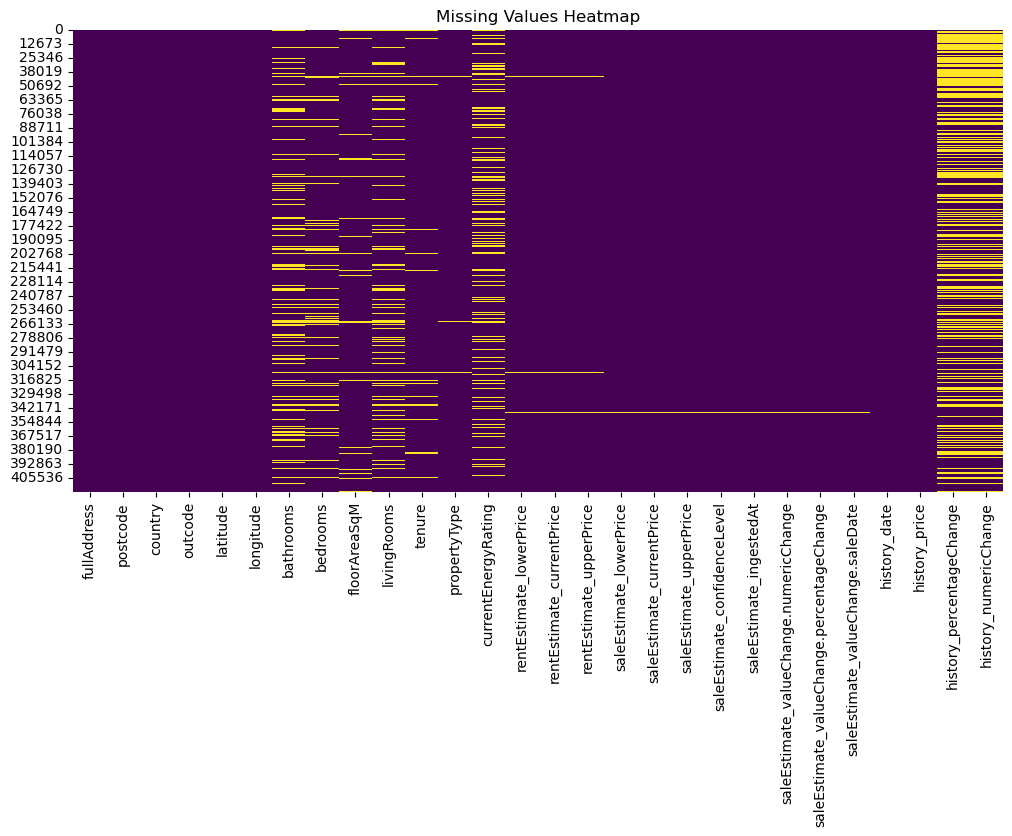

In [52]:
#Visualisation of missing values

plt.figure(figsize=(12,6))

sns.heatmap(df.isna(), cbar=False, cmap='viridis')

plt.title('Missing Values Heatmap')
plt.show()

In [53]:
df.duplicated().sum()

np.int64(7)

In [54]:
df[df.duplicated(keep=False)]

,fullAddress,postcode,country,outcode,latitude,longitude,bathrooms,bedrooms,floorAreaSqM,livingRooms,...,saleEstimate_upperPrice,saleEstimate_confidenceLevel,saleEstimate_ingestedAt,saleEstimate_valueChange.numericChange,saleEstimate_valueChange.percentageChange,saleEstimate_valueChange.saleDate,history_date,history_price,history_percentageChange,history_numericChange
35693,"Flat 3, 66 Weymouth Street, London, W1G 6NZ",W1G 6NZ,England,W1G,51.520106,-0.151509,1.0,1.0,47.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,1998-12-23,115000,98.275862,57000.0
35721,"Flat 3, 66 Weymouth Street, London, W1G 6NZ",W1G 6NZ,England,W1G,51.520106,-0.151509,1.0,1.0,47.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,1998-12-23,115000,98.275862,57000.0
68734,"Flat 3, 66 Weymouth Street, London, W1G 6NZ",W1G 6NZ,England,W1G,51.520106,-0.151509,1.0,1.0,47.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,2001-11-30,213000,18.333333,33000.0
68779,"Flat 3, 66 Weymouth Street, London, W1G 6NZ",W1G 6NZ,England,W1G,51.520106,-0.151509,1.0,1.0,47.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,2001-11-30,213000,18.333333,33000.0
319801,"15A Elm Bank Mansions, The Terrace, London, SW...",SW13 0NS,England,SW13,51.471805,-0.253522,1.0,2.0,78.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,2022-09-13,815000,196.363636,540000.0
319802,"15A Elm Bank Mansions, The Terrace, London, SW...",SW13 0NS,England,SW13,51.471805,-0.253522,1.0,2.0,78.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,2022-09-13,815000,196.363636,540000.0
346422,"43 Dartmouth Road, London, SE23 3HN",SE23 3HN,England,SE23,51.437733,-0.054319,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2023-03-21,131000,-53.214286,-149000.0
346473,"43 Dartmouth Road, London, SE23 3HN",SE23 3HN,England,SE23,51.437733,-0.054319,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2023-03-21,131000,-53.214286,-149000.0
346879,"Flat 31, Highlands Heath, Portsmouth Road, Lon...",SW15 3TR,England,SW15,51.448483,-0.229284,1.0,2.0,90.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,2023-03-24,540000,0.934579,5000.0
346997,"Flat 31, Highlands Heath, Portsmouth Road, Lon...",SW15 3TR,England,SW15,51.448483,-0.229284,1.0,2.0,90.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,2023-03-24,540000,0.934579,5000.0


In [55]:
df = df.drop_duplicates()

In [56]:
df.shape

(418194, 28)

In [57]:
#Confirming I have removed duplicate values
int(df.duplicated().sum())

0

In [58]:
list(columns_with_missing_data)

['history_numericChange',
 'history_percentageChange',
 'currentEnergyRating',
 'bathrooms',
 'livingRooms',
 'bedrooms',
 'floorAreaSqM',
 'tenure',
 'rentEstimate_upperPrice',
 'rentEstimate_lowerPrice',
 'rentEstimate_currentPrice',
 'propertyType',
 'saleEstimate_upperPrice',
 'saleEstimate_valueChange.saleDate',
 'saleEstimate_valueChange.percentageChange',
 'saleEstimate_valueChange.numericChange',
 'saleEstimate_ingestedAt',
 'saleEstimate_confidenceLevel',
 'saleEstimate_currentPrice',
 'saleEstimate_lowerPrice']

### **Problematic Data Analysis**

#### Missing Data and Duplicate Observation


Initial exploration of the dataset shows that 20 columns contain substantial missing data, with the proportion of missing data reaching as high as 40% in some features. These columns will require careful consideration during initial data cleaning, as high levels of missing data can reduce model reliability. 

In addition, 7 duplicate rows were identified within the dataset of 418,201 observations. Given the extremely small proportion of duplicates relative to overall dataset size, these rows were removed as they provide no additional information. 

The features that contained missing values, include: 

### Property characteristics
- bedrooms, bathrooms, livingRooms, floorAreaSqM, tenure, propertyType

### Energy efficiency
- currentEnergyRating

### Price history variables
- history_numericChange, history_percentageChange

### Rental estimates
- rentEstimate_lowerPrice, rentEstimate_currentPrice, rentEstimate_upperPrice

### Sale estimates and related features
- saleEstimate_lowerPrice, saleEstimate_currentPrice, saleEstimate_upperPrice, saleEstimate_confidenceLevel,  saleEstimate_ingestedAt, saleEstimate_valueChange.numericChange, saleEstimate_valueChange.percentageChange, saleEstimate_valueChange.saleDate


Given the level of missing data observed, it is important to determine an appropriate strategy for handling incomplete features to ensure robust model performance.








## 1.4 Initial Data Cleaning

### Feature Exclusion

We exclude variables relating to price estimates, rental estimates, and historic price changes, as these values have already been generated by external models. Including model-derived estimates would introduce data leakage, since they are strongly correlated with the target variable (Historic_Price) and would artificially improve predictive performance. As our goal is to build an independent model based on property characteristics, these features are not appropriate inputs for our analysis.

The Country variable is also removed because all observations in the dataset relate to properties located in England. Since this feature has no variation across the dataset, it will not contribute any useful information for prediction and can be excluded.

Finally, Full Address and Postcode are removed due to their extremely high cardinality, which can lead to sparse feature representations and increased risk of overfitting. We instead retain Outcode, which captures broader geographic patterns and provides useful location information while maintaining sufficient generalisation for robust modelling.

In [59]:
#Country Value Counts. 
df['country'].value_counts()

country
England    418194
Name: count, dtype: int64

In [60]:
#Cardinality of Full Address,Postcode and Outcode.

cardinality_df = df[['fullAddress','postcode', 'outcode']]

cardinality_summary = (cardinality_df.nunique().to_frame(name="Cardinality"))

cardinality_summary


,Cardinality
fullAddress,137760
postcode,48392
outcode,168


In [61]:
# Drop columns
price_estimate_cols = [
    "rentEstimate_lowerPrice",
    "rentEstimate_currentPrice",
    "rentEstimate_upperPrice",
    "saleEstimate_lowerPrice",
    "saleEstimate_currentPrice",
    "saleEstimate_upperPrice",
    "saleEstimate_confidenceLevel",
    "saleEstimate_ingestedAt",
    "saleEstimate_valueChange.numericChange",
    "saleEstimate_valueChange.percentageChange",
    "saleEstimate_valueChange.saleDate",
    "history_percentageChange",
    "history_numericChange"
]

country_cols = [
    "country"
]

location_cols = [
    "fullAddress",
    "postcode"
]

drop_cols = price_estimate_cols + country_cols + location_cols

df_ml = df.drop(columns=drop_cols, errors="ignore").copy()


In [62]:
df_ml.sample(3)

,outcode,latitude,longitude,bathrooms,bedrooms,floorAreaSqM,livingRooms,tenure,propertyType,currentEnergyRating,history_date,history_price
278657,SW9,51.462830,-0.118611,NaN,1.0,63.0,1.0,Leasehold,Purpose Built Flat,C,2021-06-01,385000
239255,SE13,51.463538,-0.006951,NaN,4.0,160.0,2.0,Freehold,Semi-Detached House,E,2018-07-23,885000
330934,WC1A,51.517909,-0.122439,1.0,1.0,40.0,1.0,Leasehold,Converted Flat,D,2022-11-25,525000


In [63]:
df_ml.info()

<class 'pandas.core.frame.DataFrame'>
Index: 418194 entries, 0 to 418200
Data columns (total 12 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   outcode              418194 non-null  object 
 1   latitude             418194 non-null  float64
 2   longitude            418194 non-null  float64
 3   bathrooms            340264 non-null  float64
 4   bedrooms             377659 non-null  float64
 5   floorAreaSqM         392985 non-null  float64
 6   livingRooms          357695 non-null  float64
 7   tenure               406682 non-null  object 
 8   propertyType         417058 non-null  object 
 9   currentEnergyRating  333668 non-null  object 
 10  history_date         418194 non-null  object 
 11  history_price        418194 non-null  int64  
dtypes: float64(6), int64(1), object(5)
memory usage: 41.5+ MB


### **Changing Data Types**

- history_date to be converted to datetime
- bathrooms, bedrooms and livingRooms to be converted to integer. However, as they currently contain NaN values we will store them as floats until we have decided how to deal with these.




In [64]:
# Convert history_date to datetime
df_ml["history_date"] = pd.to_datetime(df_ml["history_date"], errors="coerce")

In [65]:
df_ml.info()

<class 'pandas.core.frame.DataFrame'>
Index: 418194 entries, 0 to 418200
Data columns (total 12 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   outcode              418194 non-null  object        
 1   latitude             418194 non-null  float64       
 2   longitude            418194 non-null  float64       
 3   bathrooms            340264 non-null  float64       
 4   bedrooms             377659 non-null  float64       
 5   floorAreaSqM         392985 non-null  float64       
 6   livingRooms          357695 non-null  float64       
 7   tenure               406682 non-null  object        
 8   propertyType         417058 non-null  object        
 9   currentEnergyRating  333668 non-null  object        
 10  history_date         418194 non-null  datetime64[ns]
 11  history_price        418194 non-null  int64         
dtypes: datetime64[ns](1), float64(6), int64(1), object(4)
memory usage: 41.5+ MB


## Feature Type Classification

| Feature | Category | Sub-Type | Description |
|--------|----------|----------|-------------|
| outcode | Categorical | Nominal | Broad geographic location identifier derived from postcode |
| latitude | Numerical | Continuous | Geographic coordinate representing north–south position |
| longitude | Numerical | Continuous | Geographic coordinate representing east–west position |
| bathrooms | Numerical | Discrete | Number of bathrooms in the property |
| bedrooms | Numerical | Discrete | Number of bedrooms in the property |
| floorAreaSqM | Numerical | Continuous | Total floor area of the property in square metres |
| livingRooms | Numerical | Discrete | Number of living rooms in the property |
| tenure | Categorical | Nominal | Ownership type (e.g. Freehold, Leasehold) |
| propertyType | Categorical | Nominal | Structural classification of property (e.g. Detached, Flat) |
| currentEnergyRating | Categorical | Ordinal | Energy efficiency rating ordered from A (best) to G (worst) |
| history_date | Date/Time | Temporal | Date of historic property transaction |
| history_price | Numerical | Continuous | Recorded historic sale price of the property (target variable) |





## Feature Engineering

To improve our dataset and model performance, several additional features were engineered from the existing variables. These features capture additional information about property characteristics, location effects, and time-related patterns that may influence house prices.

---

### Temporal Features

| Feature | Description | Rationale |
|--------|-------------|-----------|
| sale_year | Year extracted from the historical sale date | Captures long-term trends in house prices over time |
| years_since_sale | Number of years since the property was sold | Accounts for changes in the housing market over time |
| sale_month | Month extracted from sale date | Captures potential seasonal variation in housing prices |

These features allow the model to account for time-related patterns such as market growth, economic cycles, and seasonality.

---

### Property Size & Layout Features

| Feature | Description | Rationale |
|--------|-------------|-----------|
| total_rooms | Total number of bedrooms and living rooms | Proxy for overall property size |
| bathrooms_per_bedroom | Ratio of bathrooms to bedrooms | Higher ratios may indicate higher quality or more spacious layouts |
| sqm_per_room | Average floor area per room | Distinguishes between more spacious and more compact properties |

These features provide more informative measures of property size and layout than individual room counts alone and floorareasqm

---

## Spatial Features

| Feature | Description | Rationale |
|---|---|---|
| `lat_lon_interaction` | Interaction between latitude and longitude | Captures geographic patterns and regional variation in house prices |
| `haversine_distance` | Great-circle distance between a property and Central London | Captures the effect of proximity to a major economic and commercial centre |

Location is one of the strongest determinants of property value. Combining latitude and longitude enables the model to better identify spatial clusters in pricing patterns. Additionally, the Haversine distance feature was introduced to measure how far properties are located from Central London, allowing the model to capture the influence of accessibility and proximity to a key urban centre on house prices.



In [66]:
#Implementation

# Date-based features
df_ml["sale_year"] = df_ml["history_date"].dt.year #converts history date to year
df_ml["years_since_sale"] = 2026 - df_ml["sale_year"]  # years since sale (inflationary)
df_ml["sale_month"] = df_ml["history_date"].dt.month  #helps pick up seasonality

# Property features
df_ml["total_rooms"] = df_ml["bedrooms"] + df_ml["livingRooms"]  #overall property size signal (bathrooms not included)


df_ml["bathrooms_per_bedroom"] = np.where(   #more bathrooms per bedroom = more luxury
    df_ml["bedrooms"] > 0,
    df_ml["bathrooms"] / df_ml["bedrooms"],
    np.nan
)

df_ml["sqm_per_room"] = np.where(    #distinguishes between spacious and compact properties
    df_ml["total_rooms"] > 0,
    df_ml["floorAreaSqM"] / df_ml["total_rooms"],
    np.nan
)

# Location interaction feature
df_ml["lat_lon_interaction"] = df_ml["latitude"] * df_ml["longitude"]   # interaction helps to detect geographic clusters.



In [67]:
# Add distance to central London
# ============================================================

def haversine_distance(lat1, lon1, lat2, lon2): #earth is curved
    """
    Calculate distance between two lat/lon points in kilometres.
    """
    R = 6371  # Earth radius in km

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat1 - lat2
    dlon = lon1 - lon2

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat2) * np.cos(lat1) * np.sin(dlon / 2) ** 2
    )

    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

In [68]:
# Central London coordinates
central_london_lat = 51.5074
central_london_lon = -0.1278

# Add new feature to your full dataset BEFORE splitting
df_ml["distance_to_central_london_km"] = haversine_distance(
    df_ml["latitude"],
    df_ml["longitude"],
    central_london_lat,
    central_london_lon
)

In [69]:
df_ml['distance_to_central_london_km'].describe()

count    418194.000000
mean          7.934181
std           3.948829
min           0.077540
25%           4.796187
50%           8.033149
75%          10.840750
max          19.663539
Name: distance_to_central_london_km, dtype: float64

In [70]:
df_ml.info()

<class 'pandas.core.frame.DataFrame'>
Index: 418194 entries, 0 to 418200
Data columns (total 20 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   outcode                        418194 non-null  object        
 1   latitude                       418194 non-null  float64       
 2   longitude                      418194 non-null  float64       
 3   bathrooms                      340264 non-null  float64       
 4   bedrooms                       377659 non-null  float64       
 5   floorAreaSqM                   392985 non-null  float64       
 6   livingRooms                    357695 non-null  float64       
 7   tenure                         406682 non-null  object        
 8   propertyType                   417058 non-null  object        
 9   currentEnergyRating            333668 non-null  object        
 10  history_date                   418194 non-null  datetime64[ns]
 11  histo

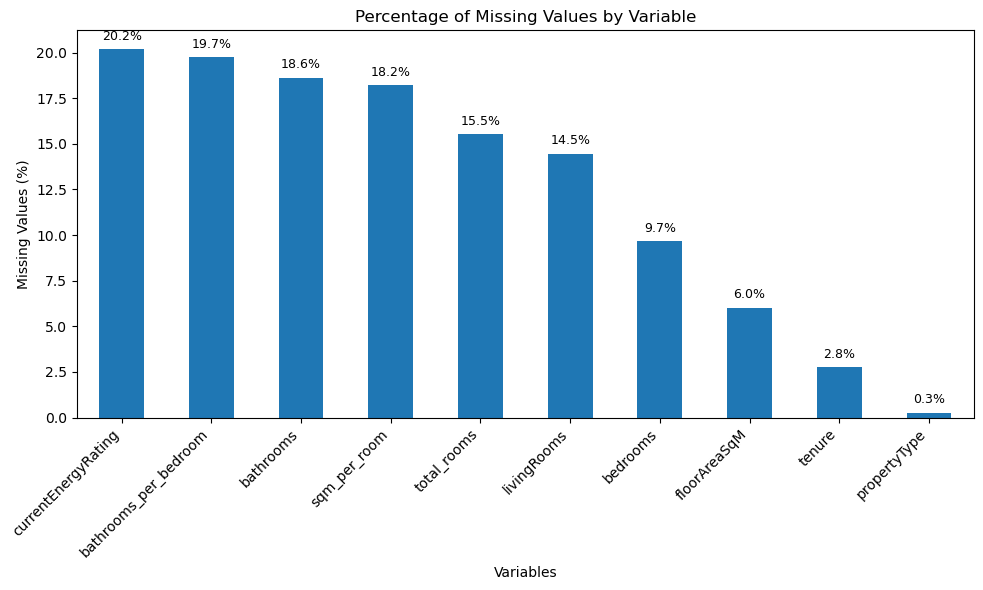

In [71]:
# ============================================================
# Missing Value Percentages
# Dissertation-Friendly Visualisation
# ============================================================

missing_pct = (
    df_ml[selected_cols_existing]
    .isna()
    .mean()
    .sort_values(ascending=False)
    * 100
)

missing_pct = missing_pct[missing_pct > 0]

plt.figure(figsize=(10, 6))

missing_pct.plot(kind="bar")

plt.ylabel("Missing Values (%)")
plt.xlabel("Variables")
plt.title("Percentage of Missing Values by Variable")

plt.xticks(rotation=45, ha="right")

# Add value labels
for i, v in enumerate(missing_pct):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

In [72]:
#Missing Value Check
missing_cols = df_ml.isna().sum().sort_values(ascending=False)
missing_cols[missing_cols >0]

currentEnergyRating      84526
bathrooms_per_bedroom    82580
bathrooms                77930
sqm_per_room             76163
total_rooms              64969
livingRooms              60499
bedrooms                 40535
floorAreaSqM             25209
tenure                   11512
propertyType              1136
dtype: int64

In [73]:

missing_data = missing_cols[missing_cols>0].index
df_ml[missing_data].isna().mean().round(3)*100

currentEnergyRating      20.2
bathrooms_per_bedroom    19.7
bathrooms                18.6
sqm_per_room             18.2
total_rooms              15.5
livingRooms              14.5
bedrooms                  9.7
floorAreaSqM              6.0
tenure                    2.8
propertyType              0.3
dtype: float64

In [74]:
df_ml.head()

,outcode,latitude,longitude,bathrooms,bedrooms,floorAreaSqM,livingRooms,tenure,propertyType,currentEnergyRating,history_date,history_price,sale_year,years_since_sale,sale_month,total_rooms,bathrooms_per_bedroom,sqm_per_room,lat_lon_interaction,distance_to_central_london_km
0,EC4A,51.517282,-0.110314,1.0,1.0,45.0,1.0,Leasehold,Purpose Built Flat,NaN,1995-01-02,830000,1995,31,1,2.0,1.00,22.500000,-5.683098,1.634534
1,EC4A,51.517282,-0.110314,NaN,NaN,NaN,NaN,Leasehold,Flat/Maisonette,NaN,1995-01-02,830000,1995,31,1,NaN,NaN,NaN,-5.683098,1.634534
2,SW1P,51.495505,-0.132379,2.0,2.0,71.0,1.0,Leasehold,Flat/Maisonette,C,1995-01-03,249950,1995,31,1,3.0,1.00,23.666667,-6.816929,1.360143
3,SE5,51.478185,-0.092201,1.0,1.0,64.0,1.0,Leasehold,Flat/Maisonette,D,1995-01-03,32000,1995,31,1,2.0,1.00,32.000000,-4.746361,4.077599
4,N10,51.588774,-0.139599,1.0,4.0,137.0,2.0,Freehold,End Terrace House,D,1995-01-03,133000,1995,31,1,6.0,0.25,22.833333,-7.201757,9.085086


In [75]:
df_ml.sample(3)

,outcode,latitude,longitude,bathrooms,bedrooms,floorAreaSqM,livingRooms,tenure,propertyType,currentEnergyRating,history_date,history_price,sale_year,years_since_sale,sale_month,total_rooms,bathrooms_per_bedroom,sqm_per_room,lat_lon_interaction,distance_to_central_london_km
359340,SW12,51.450094,-0.154683,2.0,4.0,137.0,2.0,Freehold,Mid Terrace House,C,2023-06-28,1350000,2023,3,6,6.0,0.500000,22.833333,-7.958475,6.638541
240758,EC1M,51.520677,-0.103356,2.0,2.0,130.0,1.0,Leasehold,Flat/Maisonette,C,2018-08-31,1048500,2018,8,8,3.0,1.000000,43.333333,-5.324956,2.245199
204541,W1H,51.519509,-0.163901,2.0,3.0,124.0,NaN,Leasehold,Flat/Maisonette,E,2015-09-09,2260000,2015,11,9,NaN,0.666667,NaN,-8.444089,2.837944


## Initial Data Cleaning and Feature Preparation

During the initial data preparation stage, several steps were taken to improve the quality of the dataset and ensure that the features included in the model are both meaningful and appropriate for prediction.

### Removal of Uninformative Features

A number of variables were removed because they did not provide useful predictive information or would introduce bias into the model. In particular, features relating to estimated property values, rental estimates, and historical price changes were excluded as these variables are outputs of prior valuation models. Including model-generated estimates would introduce data leakage, as they are inherently correlated with the target variable and would artificially inflate model performance.

Additionally, highly granular location variables such as **fullAddress** and **postcode** were removed due to their extremely high cardinality. These features create a large number of unique categories, increasing model complexity and the risk of overfitting. Instead, **outcode** was retained as it provides a broader geographic grouping that captures meaningful regional variation in house prices while maintaining generalisability.

The **country** feature was also removed, as all observations relate to properties located in England and therefore the variable contains no variation.

---

### Feature Engineering

Several new features were created from the existing variables to better capture characteristics of the property, spatial effects, and temporal trends that may influence house prices.

Temporal features such as **sale_year** and **sale_month** allow the model to account for changes in the housing market over time, including long-term market trends and potential seasonal patterns. Property size and layout features such as **total_rooms**, **bathrooms_per_bedroom**, and **sqm_per_room** provide more informative measures of property size than individual room counts alone. Spatial features were also introduced, including **lat_lon_interaction**, which helps capture geographic clustering effects, and **haversine_distance**, which measures the distance of a property from Central London to account for the influence of proximity to a major economic and commercial centre on property prices.

These engineered variables aim to provide the model with richer and more interpretable signals that may improve predictive performance.

---

### Missing Data Considerations

Following feature engineering, several variables contain missing values. The proportion of missing data for each affected feature is shown below:

| Feature | % Missing |
|--------|-----------|
| currentEnergyRating | 20.2 |
| bathrooms_per_bedroom | 19.7 |
| bathrooms | 18.6 |
| sqm_per_room | 18.2 |
| total_rooms | 15.5 |
| livingRooms | 14.5 |
| bedrooms | 9.7 |
| floorAreaSqM | 6.0 |
| tenure | 2.8 |
| propertyType | 0.3 |

Although some features contain a relatively high proportion of missing values, they represent important characteristics of the property and therefore should not be removed without careful consideration. Features such as number of bedrooms, bathrooms, floor area, and energy rating are likely to be strong predictors of house price, and dropping these variables could significantly reduce model performance.

At this stage, missing values will be retained and addressed after the train–test split. This approach helps prevent data leakage, as imputing values using information from the entire dataset could unintentionally introduce bias into the model.

It is important not to replace missing values with zero, as values such as zero bedrooms or zero bathrooms are not realistic and would introduce incorrect information into the dataset. Instead, missing values likely indicate incomplete records rather than true zero values.

Several imputation strategies will be considered after train_test_split, including:

- **Median imputation** for numerical features, which is robust to outliers and preserves the overall distribution of the data
- **Mode imputation** for categorical variables such as tenure or energy rating
- **Model-based imputation**, such as K-Nearest Neighbours imputation, which estimates missing values using similar observations in the dataset

The choice of imputation method will be guided by both the proportion of missing data and the importance of each feature for predicting house prices.

By postponing imputation until after the train–test split, we ensure that the model evaluation remains unbiased and reflective of real-world predictive performance.

## 1.4 EDA

**Question:**
- What patterns exist in the data that helps us predict house price


### 1.4.1 Exploring Missing Values More Closely

To better understand the structure of missing values in the dataset, I investigate whether missing values occur independently or follow identifiable patterns. I examine missingness from several perspectives, including feature-level proportions, relationships with other variables, and correlations between missing-values.







#### Step 1: Identify features containing missing values
I first identify which features contain missing values and assess the proportion of missing observations. This helps determine whether missingness is widespread or concentrated in specific variables.

The results show that missing values are primarily concentrated in structural property characteristics such as bedrooms, bathrooms, livingRooms, and floorAreaSqM, as well as engineered features derived from these variables. This suggests that missingness is not uniformly distributed across the dataset.



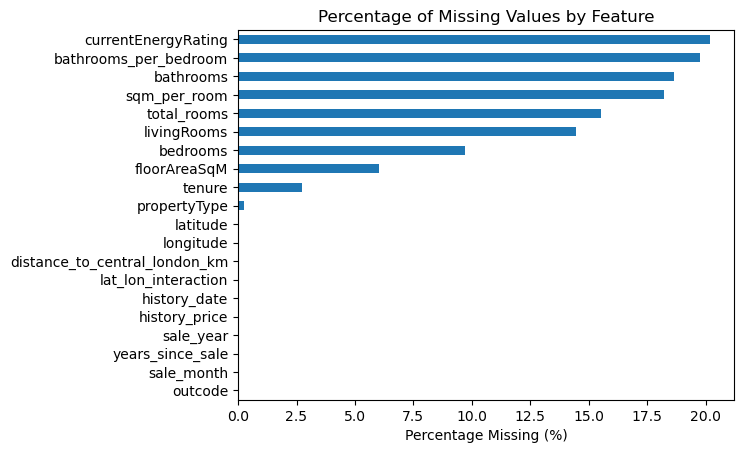

In [76]:
(df_ml.isna().mean()*100).sort_values().plot(kind="barh")

plt.xlabel("Percentage Missing (%)")
plt.title("Percentage of Missing Values by Feature")

plt.show()

#### Step 2: Investigate whether missing bedrooms depend on property type

I then examine whether missing bedroom values vary by property type.

The results show substantial variation across categories. In particular, terraced and semi-detached property categories display higher proportions of missing bedroom values, while bungalow categories show very little missingness.

This suggests that missing bedroom values depend partly on property type rather than occurring completely at random. A likely explanation is that certain listing types contain less detailed information about internal room configurations.

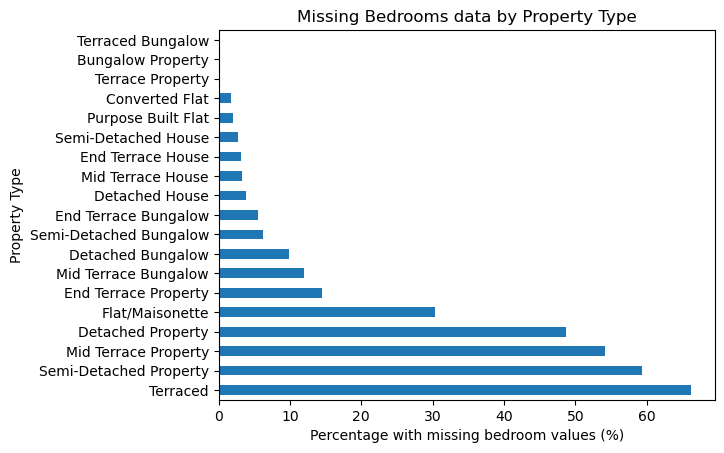

In [77]:
#Plot Percentage of Missing bedrooms per property type

(df_ml
    .assign(bedrooms_missing = df_ml["bedrooms"].isna())
    .groupby("propertyType")["bedrooms_missing"]
    .mean()
    .sort_values(ascending=False) * 100
).plot(kind='barh')

plt.xlabel("Percentage with missing bedroom values (%)")
plt.ylabel("Property Type")  
plt.title("Missing Bedrooms data by Property Type")

plt.show()

#### Step 3: Investigate whether missing energy ratings depend on sale year

Next, I assess whether missing values in currentEnergyRating vary across time by grouping missing observations by sale_year.

Although there is some variation between years, no clear or consistent trend is observed. Missing energy ratings appear relatively stable across time, suggesting that missingness is not strongly driven by when the property was sold.


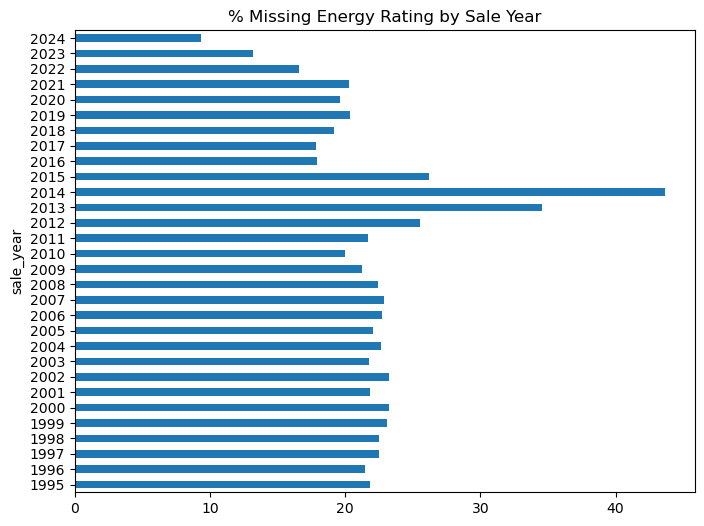

In [78]:
#Plot Percentage of Missing bathrooms per property type

(
    df_ml
    .assign(energy_missing = df_ml["currentEnergyRating"].isna())
    .groupby("sale_year")["energy_missing"]
    .mean()
    .sort_index() * 100
).plot(
    kind="barh",
    figsize=(8,6),
    title="% Missing Energy Rating by Sale Year"
);

Step 4: Examine relationships between missing variables

To determine whether missing values tend to occur together, I compute a correlation matrix of missing-value indicators. Each variable is converted into a binary indicator, where 1 represents a missing value and 0 represents an observed value.

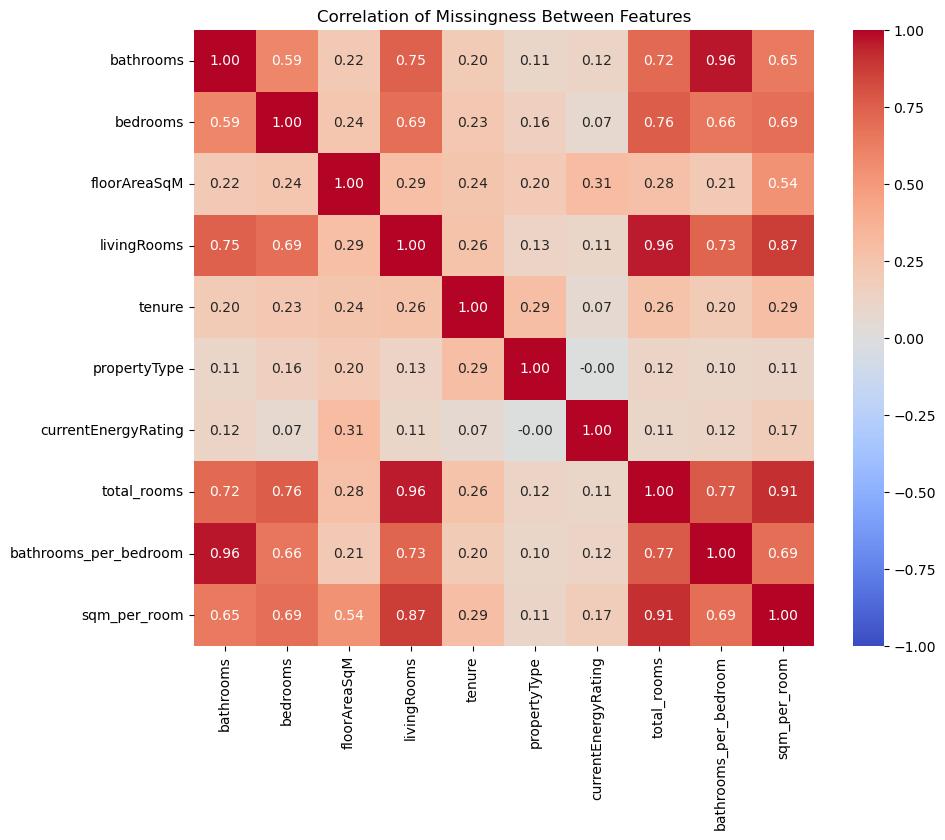

In [79]:
missing_data = (
    df_ml.isna()
    .sum()
    .loc[lambda x: x > 0]
    .index
)
missing_corr = df_ml[missing_data].isna().corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    missing_corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    fmt=".2f"
)

plt.title("Correlation of Missingness Between Features")
plt.show()


#### Step 5: Interpret relationships between engineered and original features

Strong correlations appear between engineered variables and the features used to construct them. This is expected because engineered variables rely directly on original variables.

Examples include:

| Relationship | Correlation | Explanation |
|-------------|------------|-------------|
| bathrooms ↔ bathrooms_per_bedroom | 0.96 | ratio depends on bathrooms |
| livingRooms ↔ total_rooms | 0.96 | total_rooms includes livingRooms |
| total_rooms ↔ sqm_per_room | 0.91 | sqm_per_room depends on total_rooms |
| livingRooms ↔ sqm_per_room | 0.87 | livingRooms affects the total_rooms denominator |
| bedrooms ↔ total_rooms | 0.76 | bedrooms contributes to total_rooms |

This confirms that missing values move through feature engineering. This behaviour is expected and does not indicate a problem with the dataset.

---

#### Step 6: Assess whether structural property characteristics are missing together

Moderately strong correlations are observed between key structural variables:

| Features | Correlation |
|----------|------------|
| bedrooms ↔ livingRooms | 0.69 |
| bedrooms ↔ bathrooms | 0.59 |
| livingRooms ↔ bathrooms | 0.75 |

This indicates that when one structural property characteristic is missing, others are often missing as well. This pattern suggests that some listings lack complete internal property specifications.

---

#### Step 7: Evaluate independence of floor area measurements

Correlations between `floorAreaSqM` and room-count variables are relatively weak (roughly **0.20–0.31**). This suggests that floor area measurements are recorded independently of room counts.

This may be useful during imputation, as floor area could provide additional information when estimating missing room-related values.

---

#### Step 8: Assess relationships with categorical features

Correlations between missing numerical structural variables and categorical features such as `tenure`, `propertyType`, and `currentEnergyRating` are generally low (roughly **0.00–0.30**). This suggests that missing structural information is not strongly dependent on these categorical characteristics alone.

---

### Summary of findings

From these analyses, I observe that:

- missing values are concentrated in structural property characteristics rather than distributed evenly across the dataset
- missing bedroom values vary across property types, indicating systematic rather than purely random missingness
- missing energy rating values do not show a strong time-based pattern
- engineered features inherit missing values from their source variables, as expected
- structural features such as bedrooms, bathrooms, and living rooms oftenare often missing together.
- floorAreaSqM is less strongly related to room-count missingness and may assist with imputation
- most observations still contain useful information despite partial missingness

Overall, the missing-value structure appears logical and consistent with other housing datasets. Since these variables are likely to be important predictors of house price, they are retained and missing values will be addressed later using appropriate imputation methods during the preprocessing stage after the train–test split. 


### 1.4.2 Distribution of Target Variable (history_price)


I begin by examining the distribution of the target variable, `history_price`, to better understand its scale, spread, and potential skewness. Understanding the distribution of the target variable is important because many machine learning models perform better when the target variable follows a reasonably smooth distribution without extreme outliers.


Step 1: Examing summary Statistics

I first review summary statistics of the target variable to understand the range of property prices, including minimum, maximum, median and interquartile range

I find that there appears to be a clear presence of outliers with the max value of 105,800,000 being significantly larger than the mean value. 

In [80]:
df['history_price'].describe().apply(lambda x: format(x, ',.0f'))

count        418,194
mean         639,587
std        1,327,944
min           10,000
25%          228,000
50%          400,000
75%          665,000
max      105,800,000
Name: history_price, dtype: object

Step 2: Visualise the distribution
-It is clear from these visualisations that the data set is positively skewed by high property prices. This is consistent with other house price data sets. 

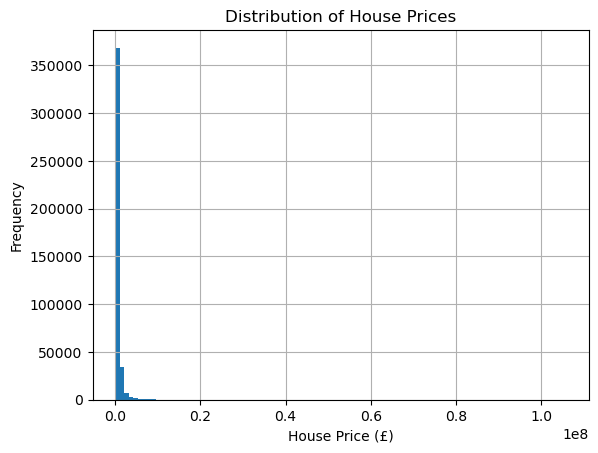

In [81]:
df_ml['history_price'].hist(bins = 100)
plt.xlabel("House Price (£)")
plt.ylabel("Frequency")
plt.title("Distribution of House Prices")

plt.show()

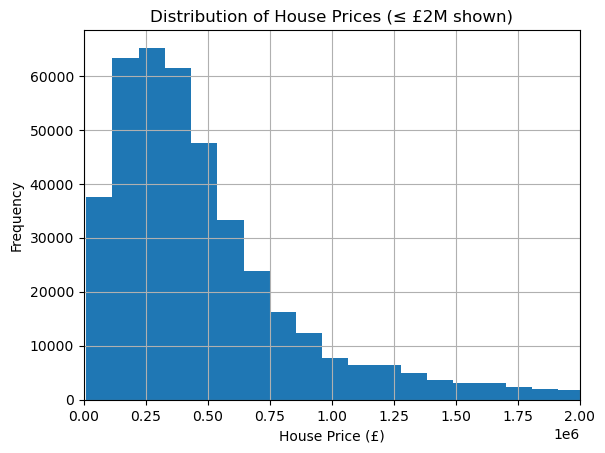

In [82]:
df_ml['history_price'].hist(bins=1000)

plt.xlim(0, 2_000_000)

plt.xlabel("House Price (£)")
plt.ylabel("Frequency")
plt.title("Distribution of House Prices (≤ £2M shown)")

plt.show()

Step 3: Box Plot of Target Variables
-Due to the presence of such large outliers we have had to limit our box plot to only include properties of less than £3,000,000

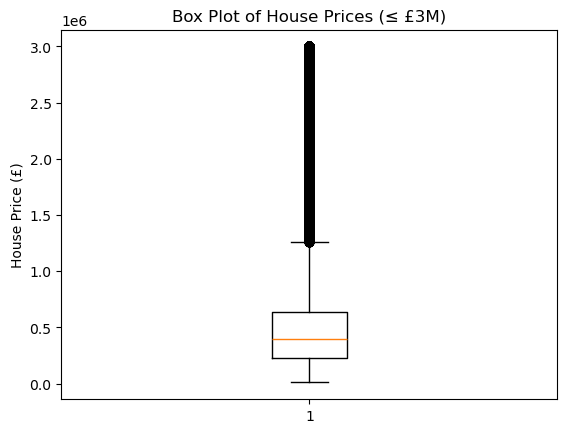

In [83]:
import matplotlib.pyplot as plt

plt.boxplot(
    df_ml[df_ml['history_price'] <= 3_000_000]['history_price'],
    vert=True
)

plt.ylabel("House Price (£)")
plt.title("Box Plot of House Prices (≤ £3M)")

plt.show()

Step 4: Log Tranform Target Variable
- Due to the presence of high value outliers, the distribution is heavily positively skewed. This can negatively mpact certain models, particularly linear models. To address this, I examine the log-transformed distribution.
- The Log transformation produces a more symmetric distribution, which may improve model performance by reducing the influence of extreme values. 

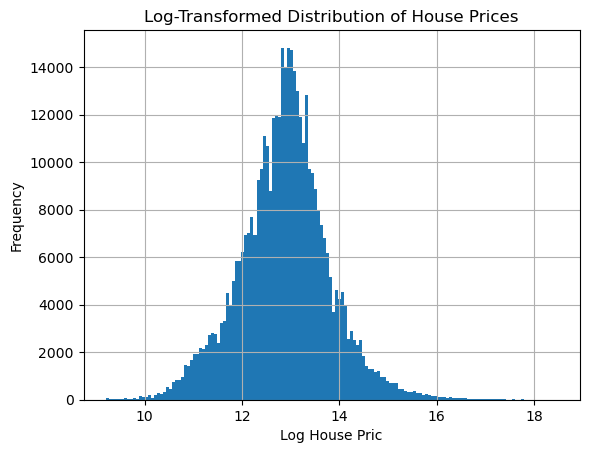

In [84]:
np.log(df_ml['history_price']).hist(bins = 150)
plt.xlabel("Log House Pric")
plt.ylabel("Frequency")
plt.title("Log-Transformed Distribution of House Prices")

plt.show()

### Summary of Findings:

From this analysis, I observe that: 
- House prices are positively skewed with a long right tail
- A small number of high value properties act as outliers
- Box plot confirms the presence of extreme high-price observations beyond the upper whisker
- A log transformation of the target variable may be considered during modelling. 

### 1.4.3 Relationships Between Features and Price

To understand which features are most influential in predicting house prices, I explore relationships between key variables and the target variable.

For the purposes of exploratory data analysis, I temporarily remove observations containing missing values. This allows relationships between variables to be visualised clearly without introducing assumptions through imputation. Missing values will be handled later during preprocessing after the train–test split.


In [85]:
df_eda = df_ml.copy()

In [86]:
df_eda_clean = df_eda.dropna()

In [87]:
df_eda_clean.info() # I have lost a lot of data but this is ok for the purposes of EDA

<class 'pandas.core.frame.DataFrame'>
Index: 266270 entries, 2 to 418200
Data columns (total 20 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   outcode                        266270 non-null  object        
 1   latitude                       266270 non-null  float64       
 2   longitude                      266270 non-null  float64       
 3   bathrooms                      266270 non-null  float64       
 4   bedrooms                       266270 non-null  float64       
 5   floorAreaSqM                   266270 non-null  float64       
 6   livingRooms                    266270 non-null  float64       
 7   tenure                         266270 non-null  object        
 8   propertyType                   266270 non-null  object        
 9   currentEnergyRating            266270 non-null  object        
 10  history_date                   266270 non-null  datetime64[ns]
 11  histo

### Step 1: Examine Summary Statistics

In [88]:
df_eda_clean.describe(include = 'all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
outcode,266270,167,SE18,5756,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,266270.0,NaN,NaN,NaN,51.505951,51.385708,51.460179,51.496239,51.551469,51.665823,0.058524
longitude,266270.0,NaN,NaN,NaN,-0.098718,-0.347055,-0.157681,-0.103063,-0.035837,0.139249,0.090425
bathrooms,266270.0,NaN,NaN,NaN,1.446937,1.0,1.0,1.0,2.0,9.0,0.711964
bedrooms,266270.0,NaN,NaN,NaN,2.520603,1.0,2.0,2.0,3.0,9.0,1.162918
floorAreaSqM,266270.0,NaN,NaN,NaN,100.709543,10.0,64.0,86.0,119.0,500.0,55.344409
livingRooms,266270.0,NaN,NaN,NaN,1.29404,1.0,1.0,1.0,1.0,7.0,0.573736
tenure,266270,4,Leasehold,149903,NaN,NaN,NaN,NaN,NaN,NaN,NaN
propertyType,266270,19,Purpose Built Flat,75632,NaN,NaN,NaN,NaN,NaN,NaN,NaN
currentEnergyRating,266270,7,D,113518,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Feature Interpretation

## Property Characteristics

### Bathrooms
Number of bathrooms ranges from **1 to 9**.  
Since **mean (1.45) > median (1)**, the distribution is **right-skewed**, meaning most properties have **1 bathroom**, while a smaller number of large or luxury properties with multiple bathrooms increase the average.

### Bedrooms
Bedrooms range from **1 to 9**.  
With **mean (2.52) > median (2)**, the distribution is **right-skewed**, indicating that most homes have **1–3 bedrooms**, but some larger houses increase the mean.

### floorAreaSqM
Floor area ranges from **10 to 500 sq.m**.  
The **mean (100.7) exceeds the median (86)**, indicating a **right-skewed distribution**. Most properties are **small to medium-sized**, while a limited number of very large properties raise the average.

### livingRooms
Living rooms range from **1 to 7**.  
Because **mean (1.29) > median (1)**, the data is **right-skewed**, suggesting most properties have **one living room**, with fewer properties offering multiple reception rooms.

### total_rooms
Total rooms range from **2 to 15**.  
With **mean (3.81) > median (3)**, the distribution is **right-skewed**, showing that most homes are relatively compact, with a small number of larger homes contributing to the upper range.

---

## Location Features

### latitude
Values range from **51.39 to 51.67**, indicating properties are located within a relatively concentrated geographic region.  
The small **standard deviation (0.058)** suggests properties are spatially clustered. This is expected as all the properties are in London.

### longitude
Values range from **-0.35 to 0.14**, again showing geographic concentration within a limited area.  
The relatively small **standard deviation (0.09)** confirms limited spatial dispersion. This is expected as all the properties are in London.

### lat_lon_interaction
This engineered feature combines latitude and longitude to capture **spatial interaction effects** that may influence pricing patterns.  
The relatively wide range suggests meaningful geographic variation in property values.

---

## Transaction Features

### history_date
Transaction dates range from **1995 to 2024**, showing a long historical coverage of property sales.  
The **median date around 2016** indicates a balanced dataset with representation of both older and relatively recent transactions.

### sale_year
Sale years range from **1995 to 2024**, with a **median of 2016**.  
This suggests the dataset captures multiple housing market cycles and trends over time.

### years_since_sale
Values range from **2 to 31 years**.  
Since **mean (12.8) > median (10)**, the distribution is **right-skewed**, indicating more recent sales are slightly more common than very old transactions.

### sale_month
Months range from **1 to 12**, with **mean ≈ median**, indicating an approximately **uniform distribution**.  
This suggests property transactions occur relatively evenly throughout the year without strong seasonal bias.



---

## Derived Ratio Features

### bathrooms_per_bedroom
Ratio ranges from **0.11 to 4.0**.  
Since **mean (0.64) > median (0.5)**, the distribution is **right-skewed**, indicating most homes have fewer bathrooms relative to bedrooms, while luxury homes with en-suite bathrooms increase the ratio.

### sqm_per_room
Space per room ranges from **1.4 to 250 sq.m**.  
With **mean (26.13) > median (25)**, the data is **right-skewed**, suggesting most homes have moderate room sizes, but some very spacious properties increase the average.

---

## Categorical Features

### outcode
There are **167 unique postcode outcodes**, with **SE18** being the most frequent (5756 occurrences).  
This suggests some postcode areas have higher transaction volumes than others.

### tenure
There are **4 tenure types**, with **Leasehold** being the most common (149,903 properties).  
This indicates a higher proportion of flats or properties where ownership of land is not included.

### propertyType
There are **19 property types**, with **Purpose Built Flat** being the most frequent (75,632 properties).  
This suggests a large share of the dataset consists of flats rather than detached or semi-detached houses.

### currentEnergyRating
There are **7 energy rating categories**, with **rating D** being most common (113,518 properties).  
This suggests many properties have moderate energy efficiency levels.

### Step 2: **Univariate Analysis**

I examine the distribution of numerical variables using boxplots in order to identify potential outliers and unusual observations. Outliers may represent genuine high-value properties, data entry errors, or extreme cases that could influence model performance.

First, I identify all numerical variables and exclude the target variable (`history_price`), as it has already been analysed separately.



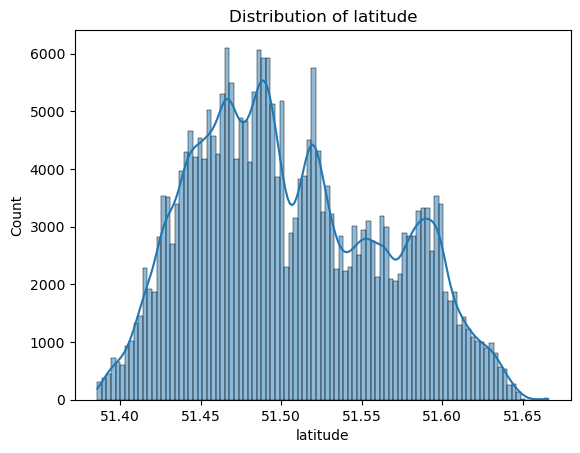

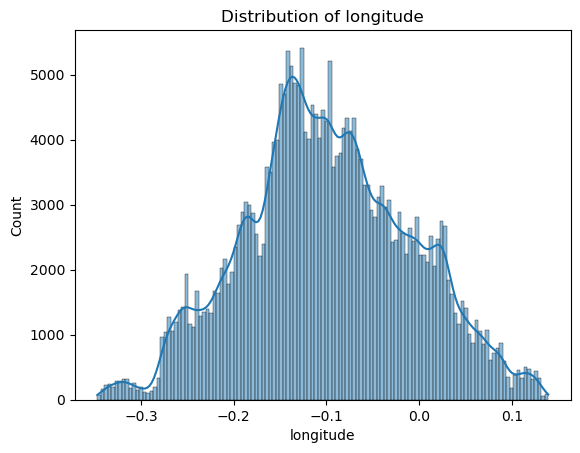

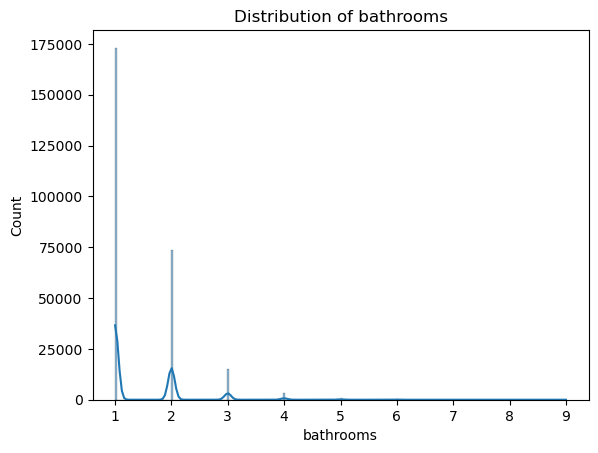

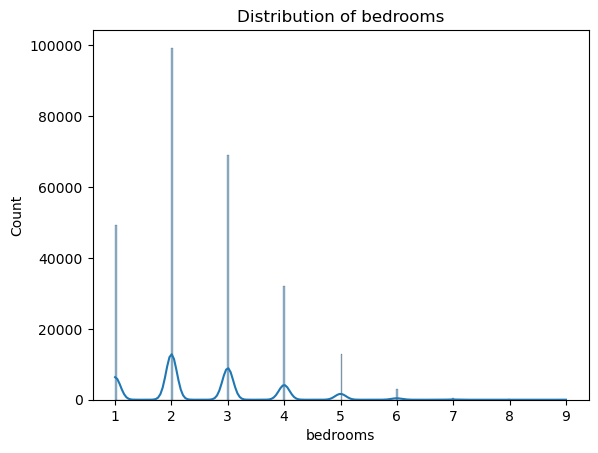

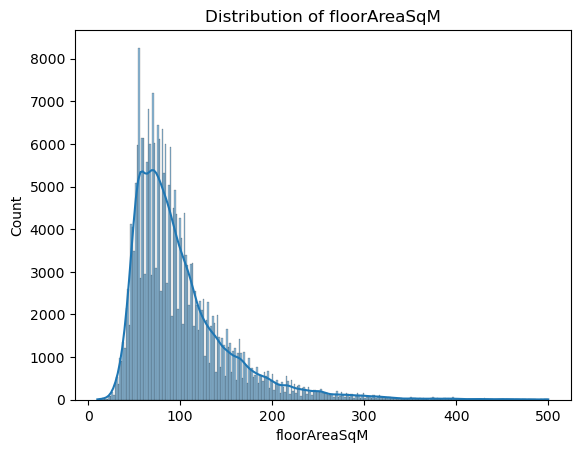

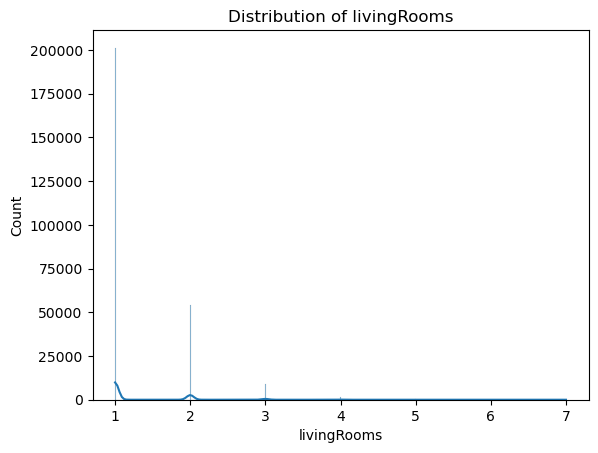

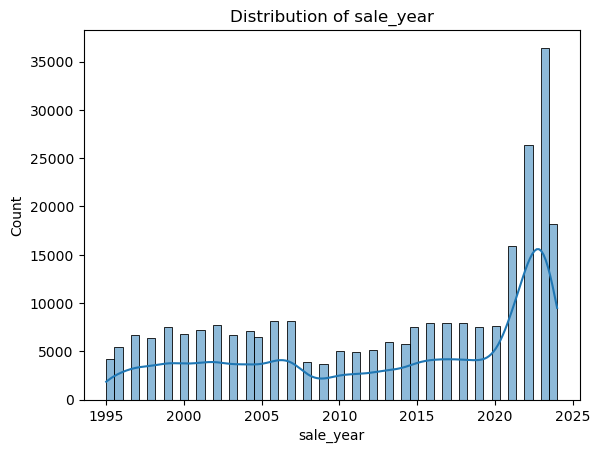

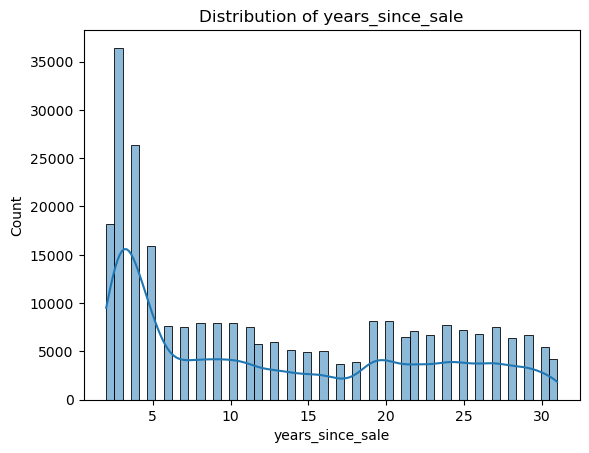

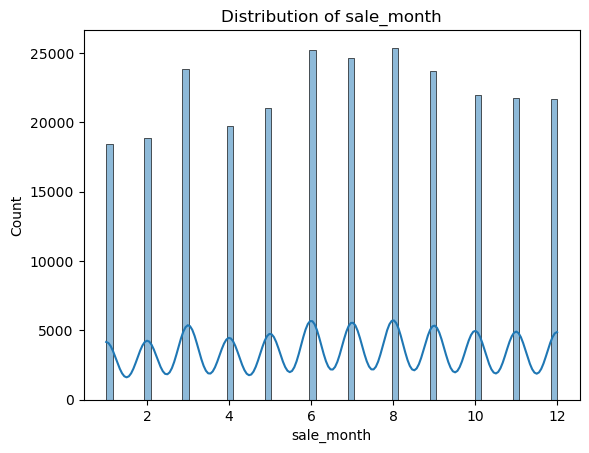

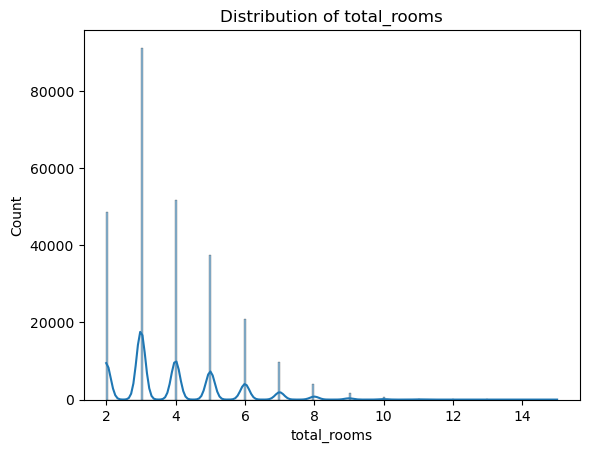

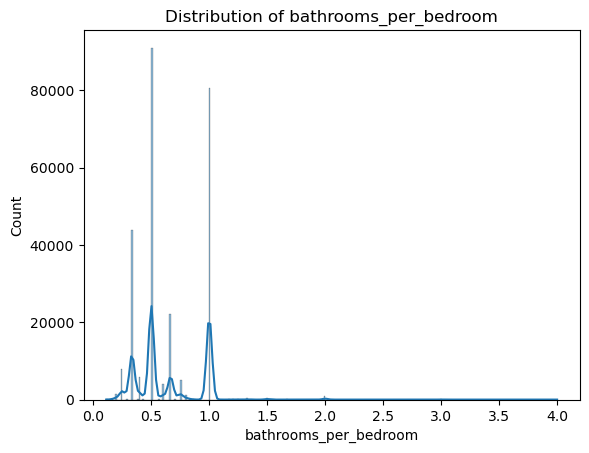

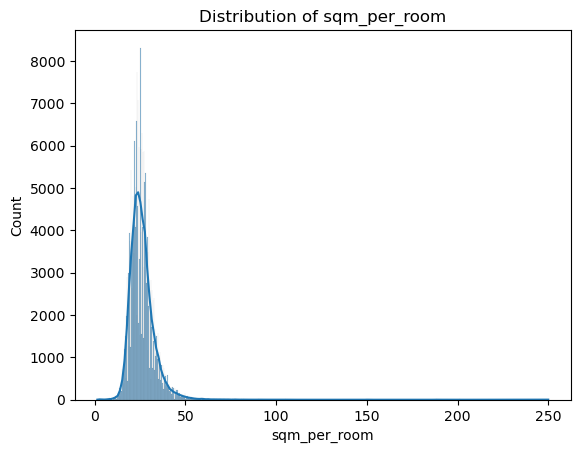

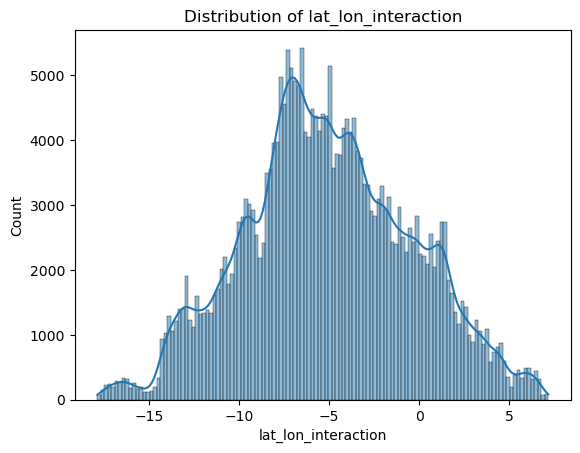

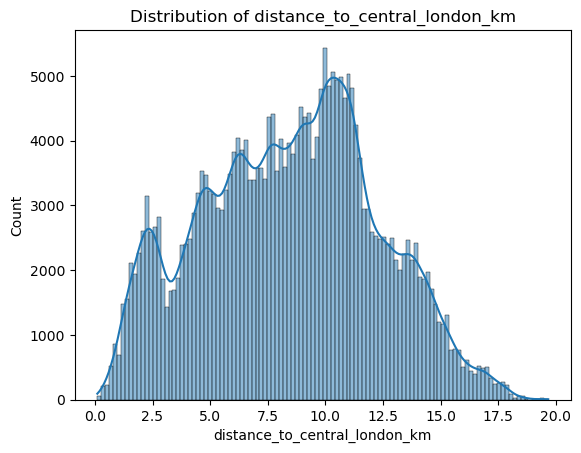

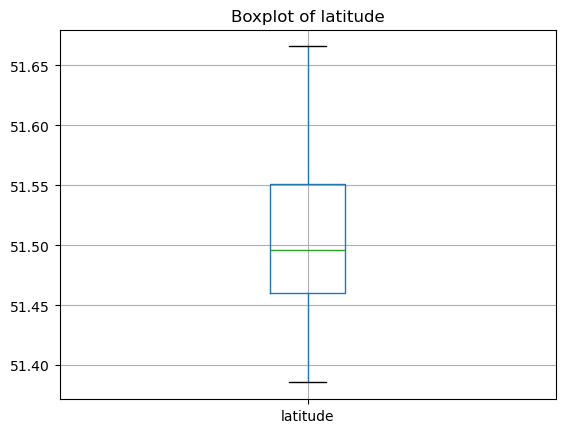

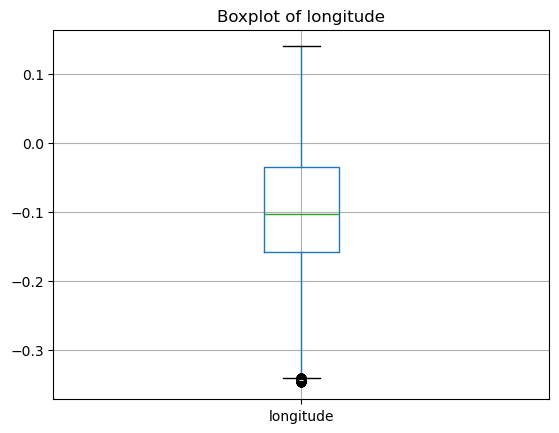

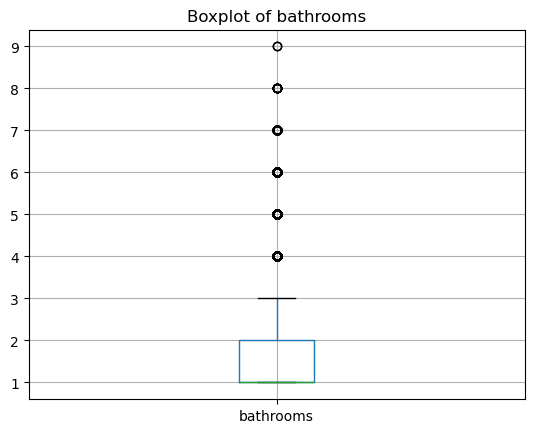

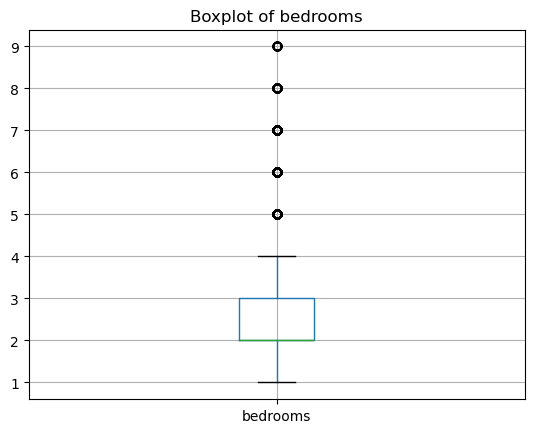

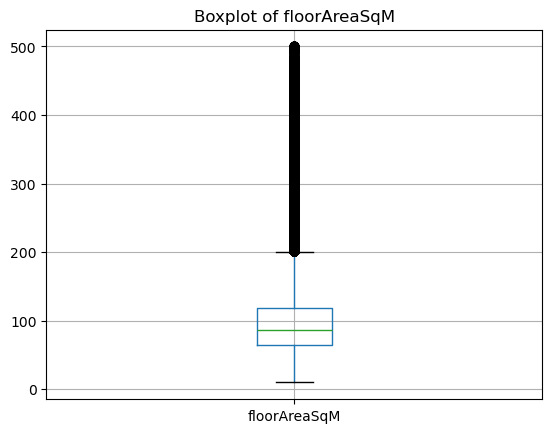

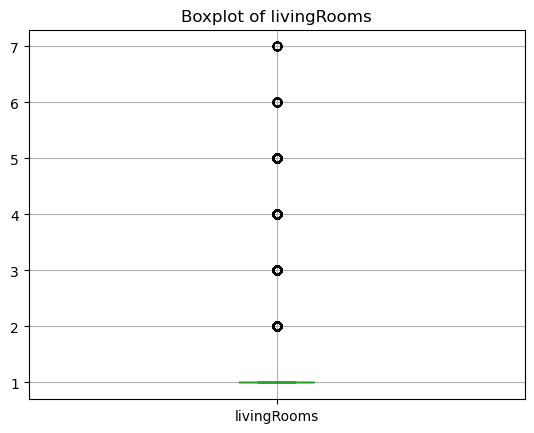

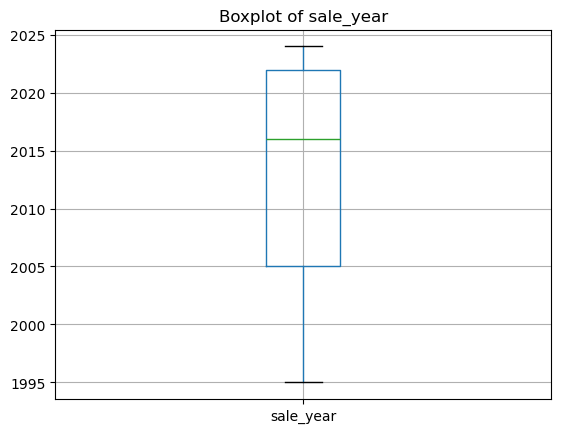

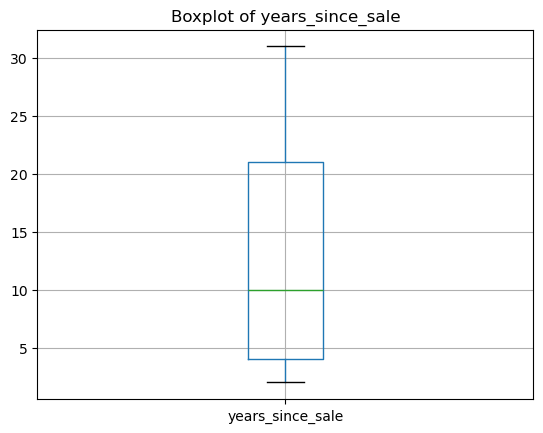

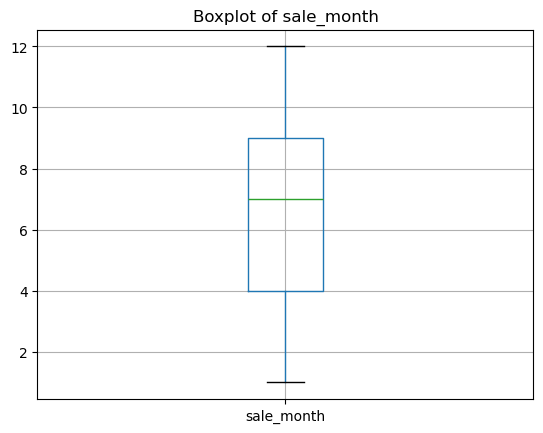

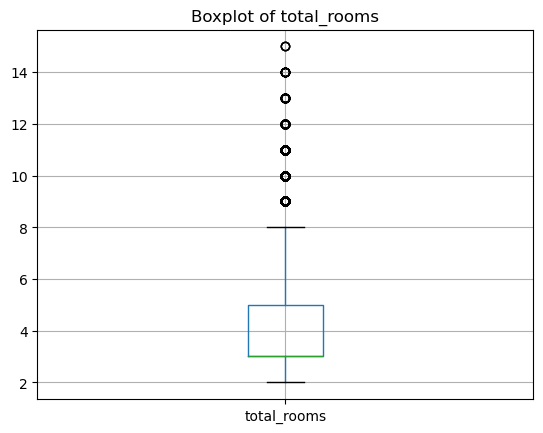

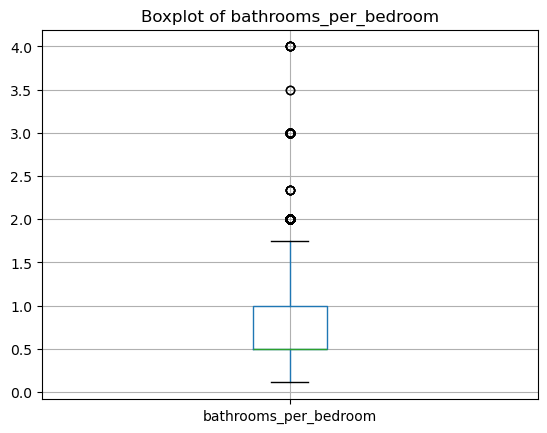

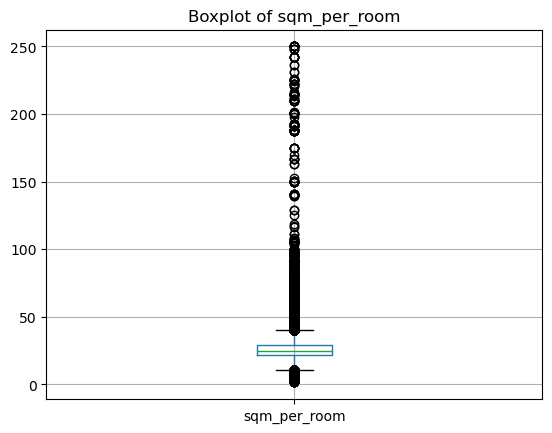

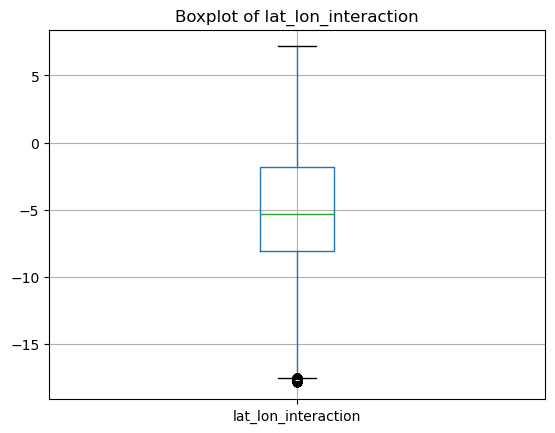

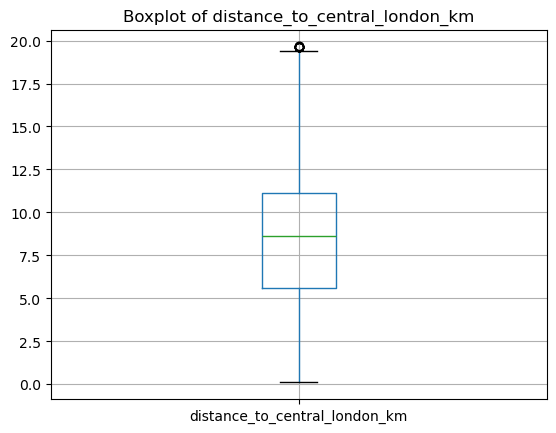

In [89]:
#Numeric Column Distribuions and Skew
numeric_cols = df_eda_clean.select_dtypes(include='number').columns

#we have already analysed our target variable history_price so we shall drop it

numeric_cols= numeric_cols.drop('history_price')

# Let's boxplot all numerical columns to see if there are any outliers
for col in numeric_cols:
    sns.histplot(df_eda_clean[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()


for col in numeric_cols:
    df_eda_clean.boxplot(column=col)
    plt.title(f'Boxplot of {col}')
    plt.show()

In [90]:
#Calculate Skew

skew_df = (
    df_eda_clean[numeric_cols]
    .skew()
    .sort_values(ascending=False)
    .to_frame(name='skew')
)

skew_df

,skew
sqm_per_room,7.294123
livingRooms,2.261004
floorAreaSqM,2.151325
bathrooms,2.011544
total_rooms,1.125329
bathrooms_per_bedroom,0.913869
bedrooms,0.796411
years_since_sale,0.454817
latitude,0.314623
lat_lon_interaction,0.063182


### Numerical variable analysis 

The distribution of the numerical variables shows that several features exhibit varying degrees of positive skewness, particularly sqm_per_room, floorAreaSqM, livingRooms, bathrooms, and total_rooms. This suggests that most properties fall within lower to mid-range values, with a smaller number of larger or more spacious properties creating a long right tail in the distributions. Such patterns are typical in housing datasets, where a minority of high-value properties differ substantially from the majority.

Features representing counts, such as bedrooms, bathrooms, and livingRooms, display discrete distributions, reflecting the natural constraints of housing characteristics. Temporal variables such as sale_year, sale_month, and years_since_sale appear reasonably well distributed and do not exhibit extreme skewness. Geographic variables latitude and longitude also demonstrate relatively stable distributions without significant anomalies.

Overall, the univariate analysis indicates that while certain variables contain extreme values, these are consistent with real-world housing variation rather than data quality issues. Transformations may be considered for highly skewed continuous variables to improve model performance, but no features were removed solely on the basis of outliers.

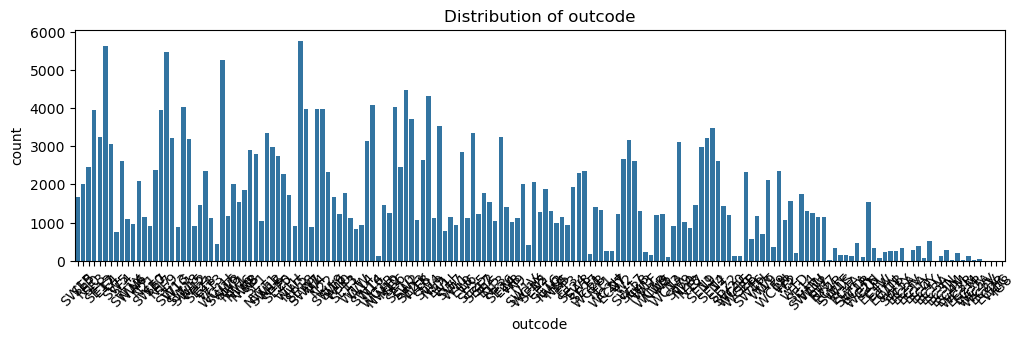

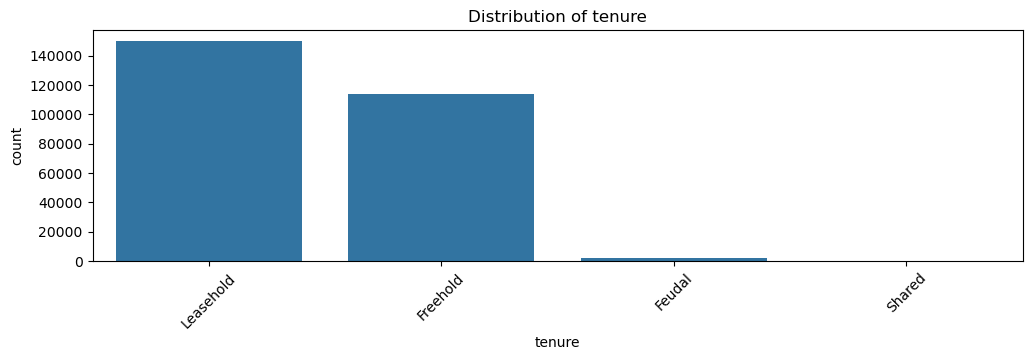

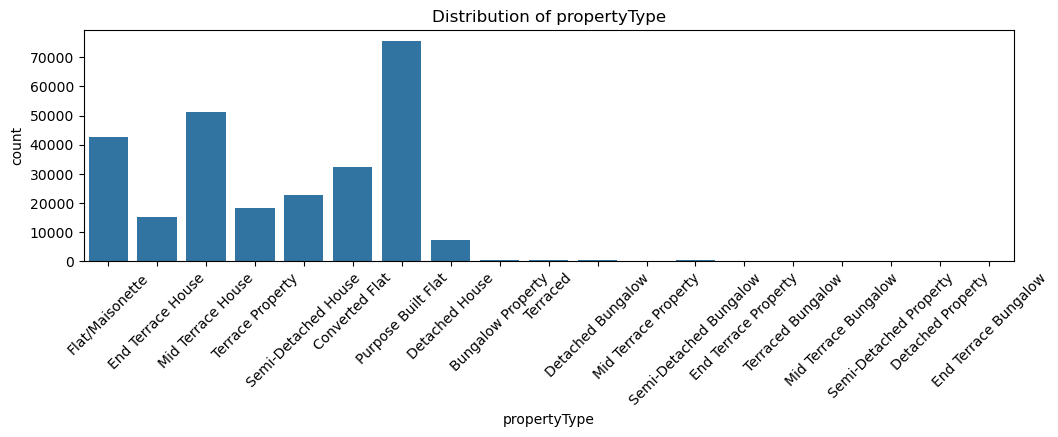

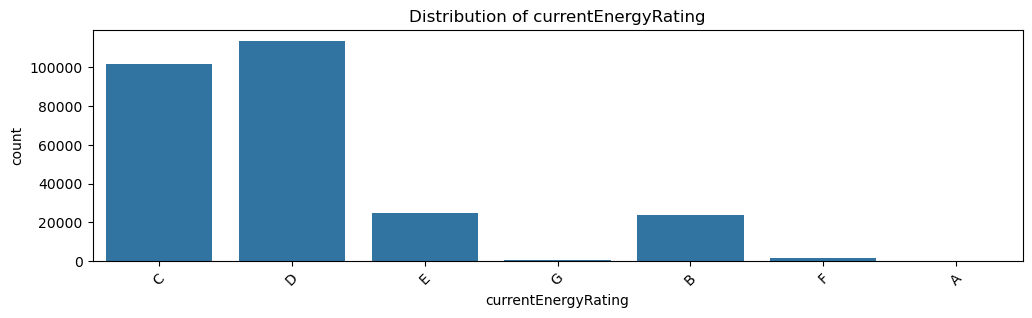

In [91]:
#Categorical Variable Distribution

cat_cols = df_eda_clean.select_dtypes(include=['object','category']).columns

for col in cat_cols:
    plt.figure(figsize=(12,3))
    sns.countplot(data=df_eda_clean, x=col)
    plt.xticks(rotation=45)
    plt.title(f'Distribution of {col}')
    plt.show()


### Categorical Variable Analysis
Categorical features were examined using count plots to understand how frequently each category appears.
The outcode variable has many unique location categories, with some areas appearing more often than others, which is expected in housing data. The tenure variable is mainly Leasehold and Freehold, with very few Shared or Feudal properties.
For propertyType, certain property structures such as flats, terraced, and semi-detached houses occur more frequently, while others appear less often but still represent valid housing types.
The currentEnergyRating distribution shows most properties fall within ratings C and D, which is typical for residential properties.
Overall, the categorical variables reflect realistic housing characteristics. Although some categories are imbalanced, this is expected and the variables are retained for modelling.

### Step 3: Bivariate Analysis

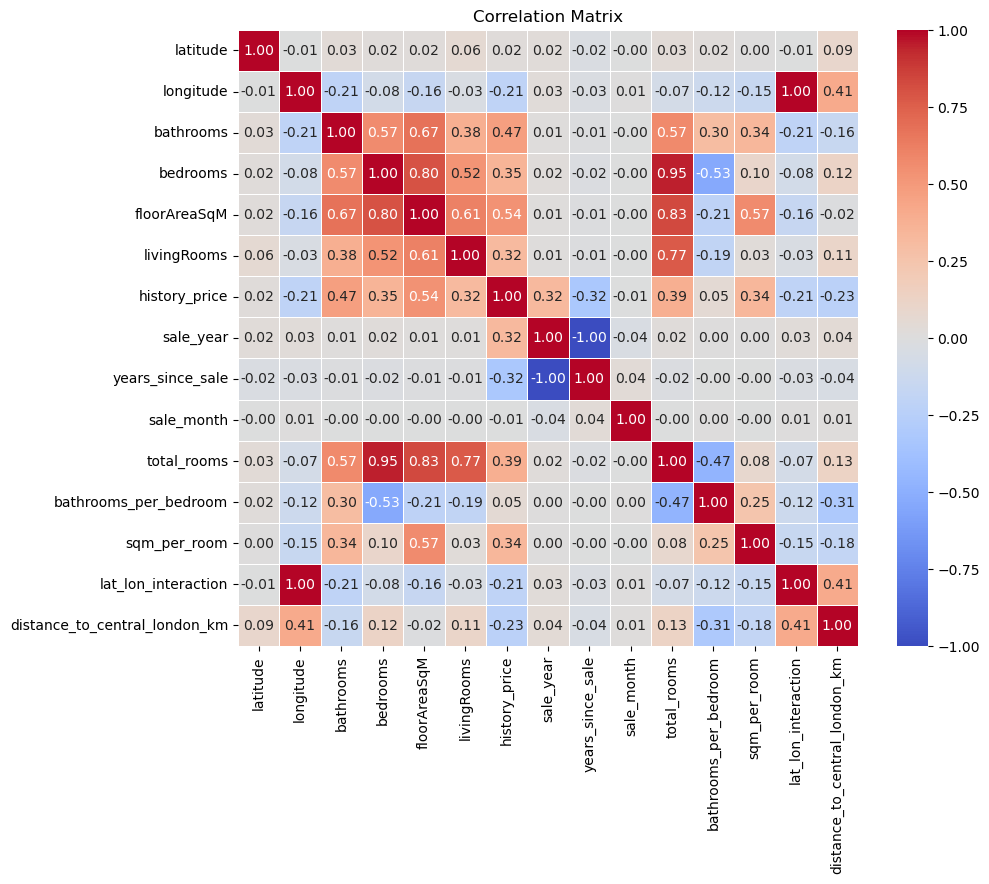

In [92]:
#Numeric Features VS Price

numeric_columns = df_eda_clean.select_dtypes(include='number').columns
corr = df_eda_clean[numeric_columns].corr(method = 'pearson')
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm', center=0, annot = True, fmt=".2f",linewidth = 0.5)
plt.title('Correlation Matrix')
plt.show()


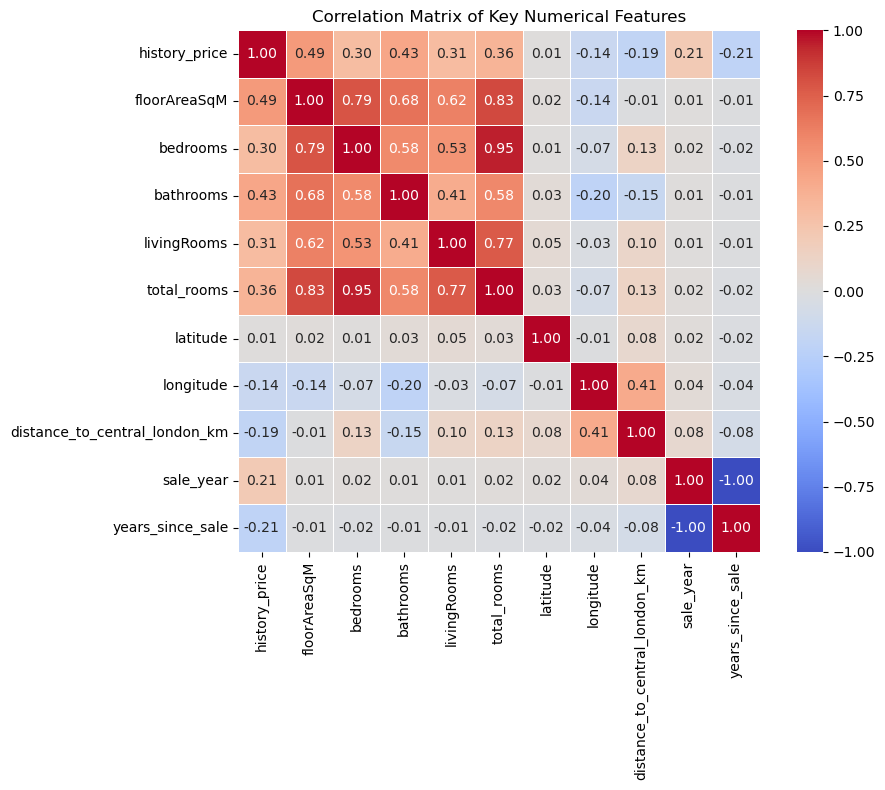

In [104]:
corr_cols = [
    "history_price",
    "floorAreaSqM",
    "bedrooms",
    "bathrooms",
    "livingRooms",
    "total_rooms",
    "latitude",
    "longitude",
    "distance_to_central_london_km",
    "sale_year",
    "years_since_sale"
]

correlation_matrix = df_ml[corr_cols].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    annot=True,          # show numbers
    fmt=".2f",           # 2 decimal places
    linewidths=0.5,
    square=True
)

plt.title("Correlation Matrix of Key Numerical Features")

plt.tight_layout()
plt.show()

### NumericalCorrelation Analysis Summary

The correlation matrix shows that property size variables have the strongest positive relationships with history_price. In particular, floorAreaSqM (0.54), bathrooms (0.47), total_rooms (0.39), bedrooms (0.35) and sqm_per_room (0.34) show moderate positive correlations, suggesting that larger properties with more space and rooms tend to have higher prices.

Strong correlations are also observed between predictor variables themselves, such as bedrooms and total_rooms (0.95) and floorAreaSqM and total_rooms (0.83), indicating that several variables measure similar aspects of property size. This is expected in housing datasets and may indicate some redundancy between features.

Time-related variables such as sale_year, sale_month, and years_since_sale show weak relationships with price, suggesting that temporal factors may have less influence on property value in this dataset.

Location variables latitude and longitude show low individual correlations with price, though location may still play an important role when combined with other variables.

Overall, the analysis indicates that property size and room-related features are likely to be the strongest predictors of house price, while time-related variables show weaker relationships.

### Numerical Pairplot

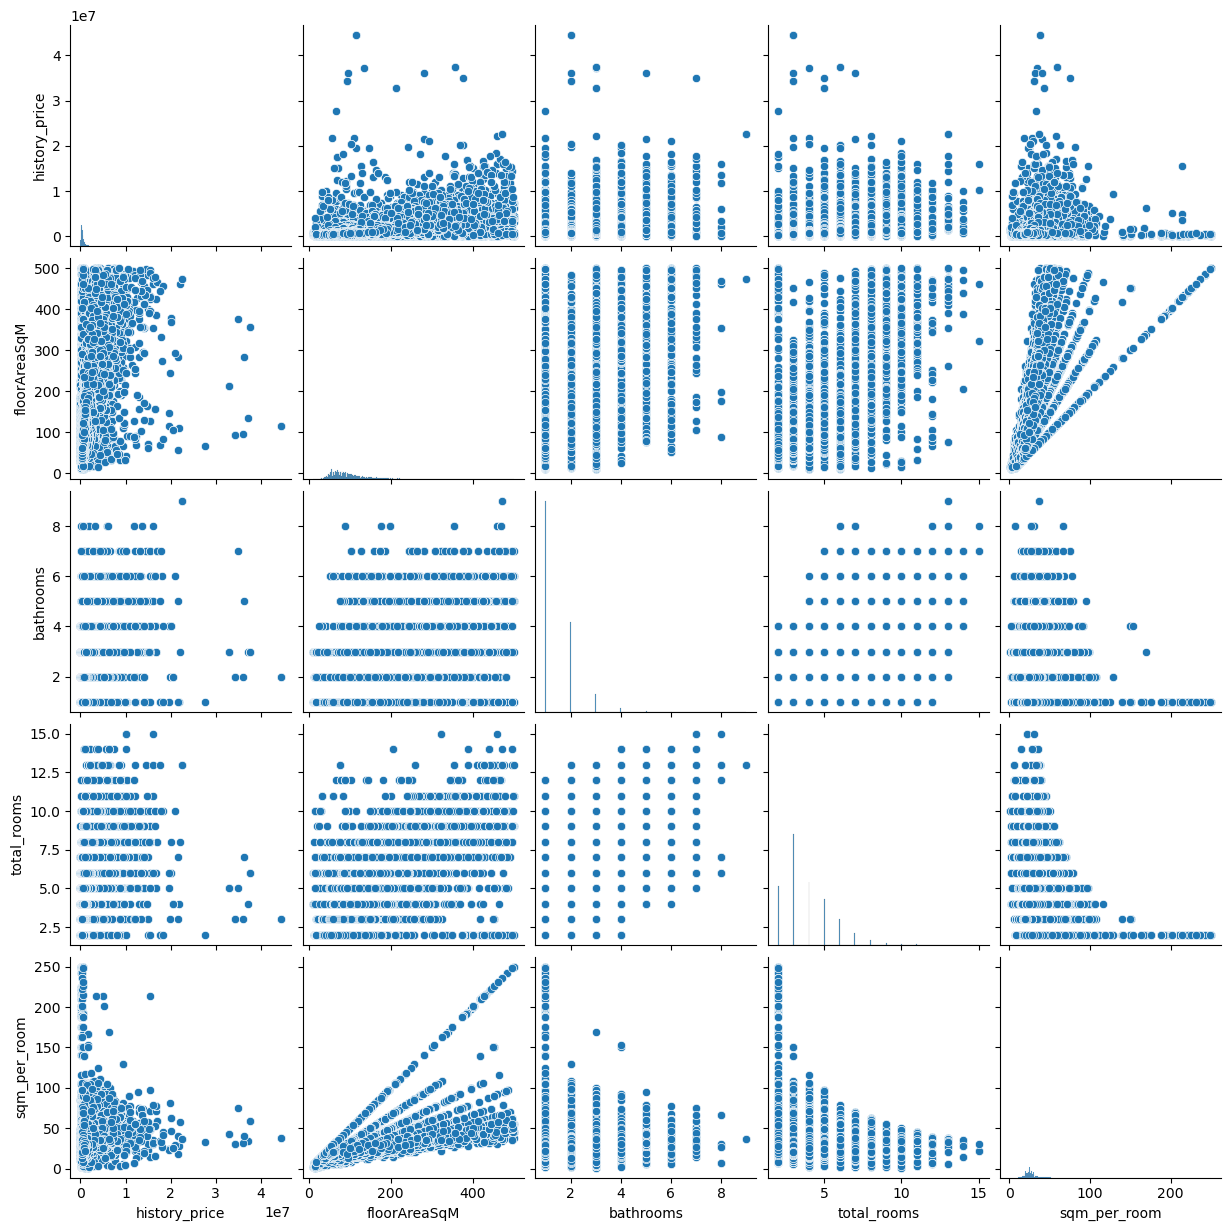

In [93]:
# From our correlation matriix we shall use the following variables in a pair plot. 

important_vars = [
    'history_price',
    'floorAreaSqM',
    'bathrooms',
    'total_rooms',
    'sqm_per_room'
]

sns.pairplot(df_eda_clean[important_vars])

### Pairplot Analysis Summary

The pairplot shows relationships between key numerical variables and history_price.

floorAreaSqM shows a clear positive relationship with price, indicating larger properties tend to be more expensive. Similar upward trends are seen for total_rooms and bathrooms, suggesting that properties with more space and rooms generally have higher values.

Strong relationships between floorAreaSqM, total_rooms, and bathrooms indicate these variables capture similar information about property size.

Overall, the plot confirms that size-related features are important predictors of house price.

### Boxplots (Categorical Vs Target)

This shows how price varies across targets

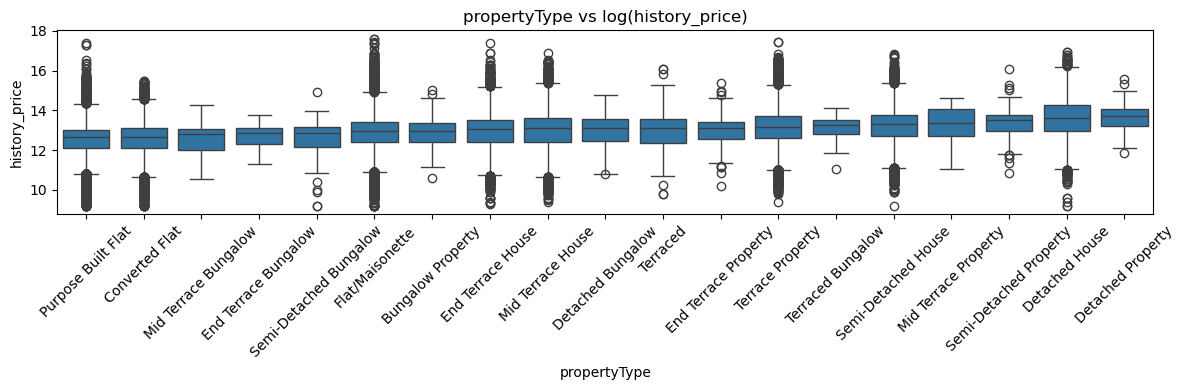

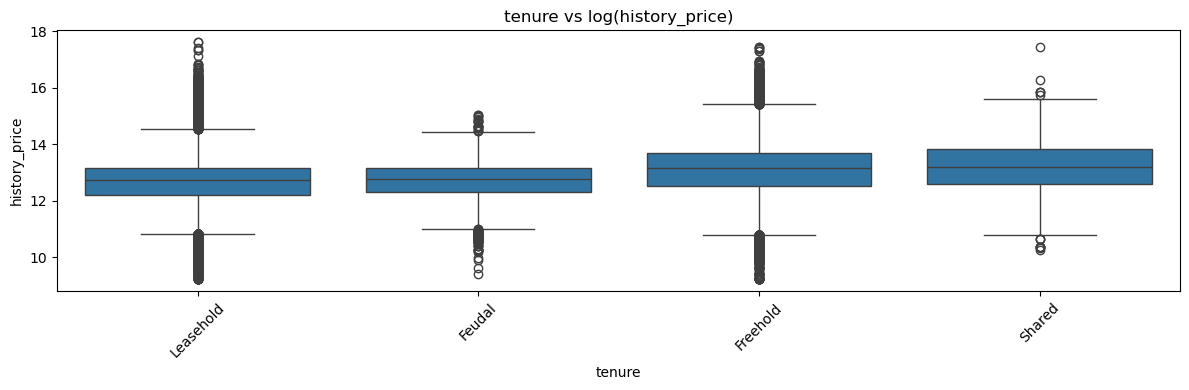

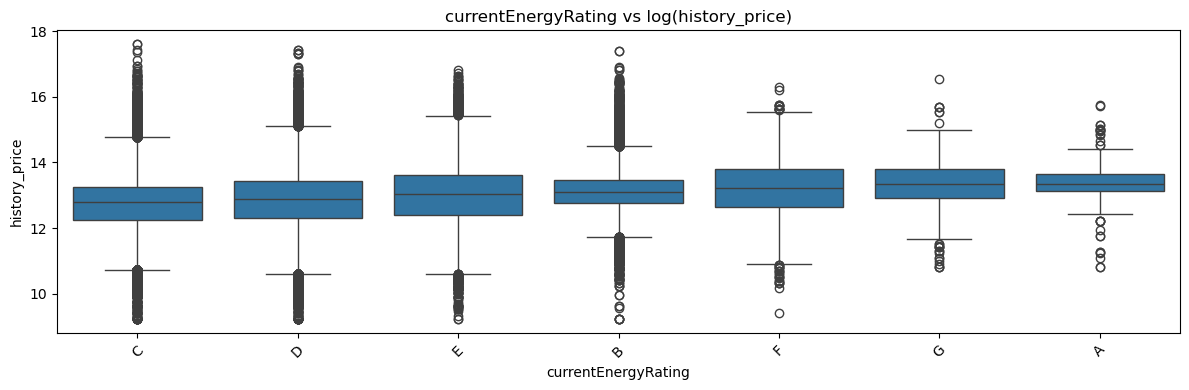

In [94]:
# History Price is log scaled
cat_cols_selected = ['propertyType', 'tenure', 'currentEnergyRating']

for col in cat_cols_selected:
    
    order = (df_eda_clean.groupby(col)['history_price'].median().sort_values().index )
    plt.figure(figsize=(12,4))

    sns.boxplot(data=df_eda_clean,x=col,y=np.log1p(df_eda_clean['history_price']),
        order=order
    )

    plt.xticks(rotation=45)
    plt.title(f'{col} vs log(history_price)')

    plt.tight_layout()
    plt.show()

Property type shows a clear price hierarchy: detached and semi-detached homes have higher median prices than flats and terraced properties. Freehold properties tend to be slightly more expensive than leasehold. Higher energy ratings show a small upward trend in price. Overall, structural property characteristics appear more influential on price than tenure or energy efficiency.

### Median Sale Price by Number of Bedrooms

This bar chart shows the relationship between the number of bedrooms and the median property sale price.

We observe a clear positive relationship, where properties with more bedrooms generally achieve higher median sale prices. This suggests that property size and capacity are important drivers of value, as larger homes are typically more desirable for families and offer greater living space.

However, this analysis does not account for the impact of inflation or changes in housing market conditions over time. Properties sold in earlier years may appear cheaper due to historical market prices rather than differences in property characteristics alone. Including time-related variables such as `sale_year` or adjusting prices for inflation could provide a more accurate comparison of property values.

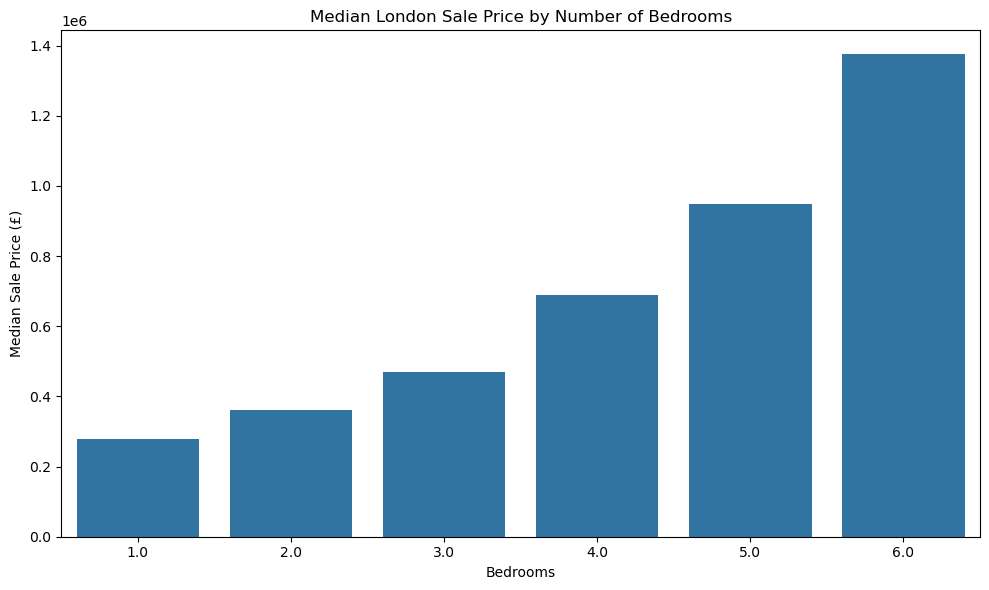

In [95]:
#Average sale price by bedrooms

# Average sale price by bedrooms
avg_by_beds = df_eda_clean.groupby('bedrooms')['history_price'].median().reset_index()
avg_by_beds = avg_by_beds[avg_by_beds['bedrooms'] <= 6]

# Plot
plt.figure(figsize=(10,6))
sns.barplot(data=avg_by_beds, x='bedrooms', y='history_price')
plt.title('Median London Sale Price by Number of Bedrooms')
plt.ylabel('Median Sale Price (£)')
plt.xlabel('Bedrooms')
plt.tight_layout()
plt.show()

#this shows us that as number of bedrooms increase so to does the value of a property. 
#However, this model does not take into account inflationarby impact of when the property was sold.

### Median House Prices vs Year

The line plot shows the trend in median house prices between 1995 and 2024.

We observe a clear long-term upward trend in property prices, increasing from approximately £75,000 in 1995 to over £550,000 in recent years. The most significant growth appears between 2013 and 2021, where prices rise steeply, indicating strong market demand and rapid property value appreciation during this period.

There is a slight dip towards the most recent years, which may reflect market cooling, economic uncertainty, or reduced transaction volumes.

Overall, the plot demonstrates the substantial impact of time and market inflation on house prices, highlighting the importance of including temporal variables such as `sale_year` or adjusting prices for inflation when building predictive models.

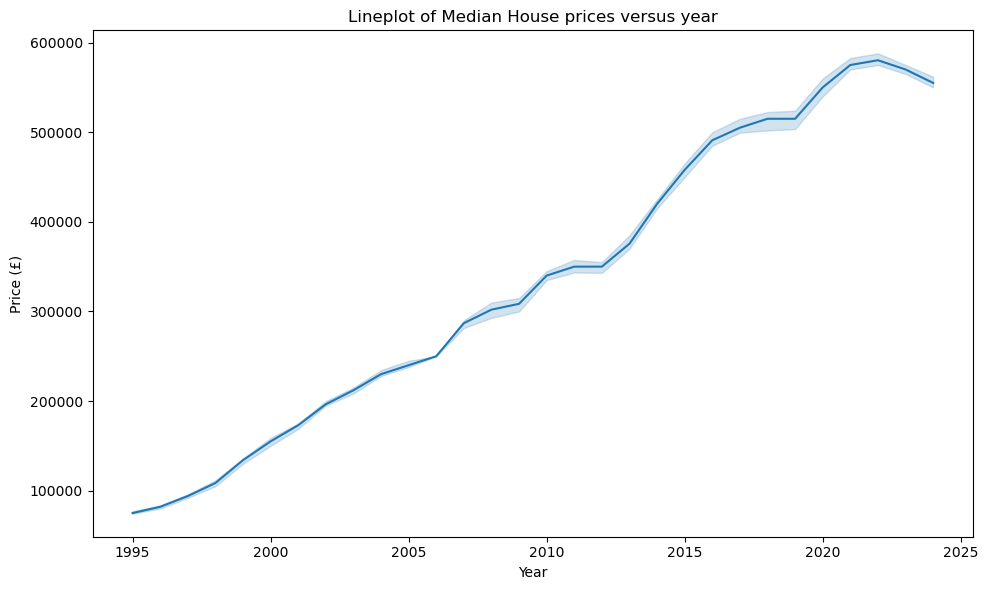

In [96]:
plt.figure(figsize=(10,6))
sns.lineplot(data=df_eda_clean,
            x='sale_year',
            y='history_price',
            estimator = np.median
           )

plt.title('Lineplot of Median House prices versus year')
plt.ylabel('Price (£)')
plt.xlabel('Year')

plt.tight_layout()
plt.show()

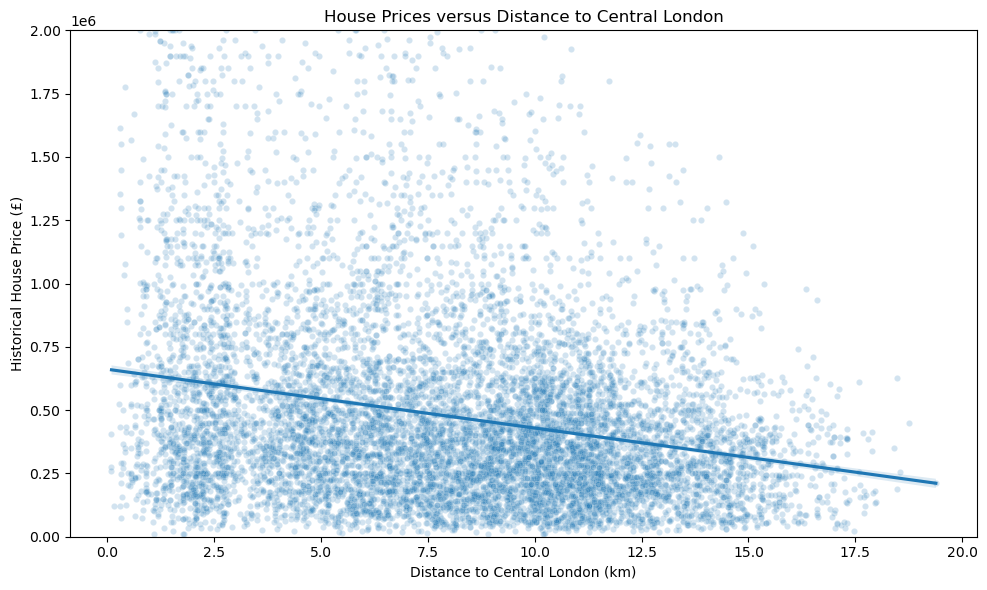

In [100]:
# House Prices Vs Distance to Central London


df_geo = df_ml[
    [
        "distance_to_central_london_km",
        "history_price"
    ]
].dropna()

# Keep prices below £2 million
df_geo = df_geo[
    df_geo["history_price"] <= 2_000_000
]

# Sample for readability
df_geo_sample = df_geo.sample(
    10000,
    random_state=9
)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_geo_sample,
    x="distance_to_central_london_km",
    y="history_price",
    alpha=0.2,
    s=20
)

sns.regplot(
    data=df_geo_sample,
    x="distance_to_central_london_km",
    y="history_price",
    scatter=False
)

plt.title("House Prices versus Distance to Central London")

plt.xlabel("Distance to Central London (km)")
plt.ylabel("Historical House Price (£)")

# Limit y-axis to £2 million
plt.ylim(0, 2_000_000)

plt.tight_layout()
plt.show()